# 📊 Telecom Customer Churn Analysis

---

**Objective:** This notebook provides a comprehensive exploratory data analysis (EDA) of a telecom company's customer dataset. The goal is to understand customer behavior, identify key drivers of churn, and extract actionable business insights that can help reduce customer attrition and improve retention strategies.

**Dataset Overview:**
- **6,043 customers** with **21 features** covering demographics, services subscribed, contract details, billing, and churn status.

---

### 📁 Table of Contents
1. [Import Libraries & Load Data](#1)
2. [Dataset Overview & Structure](#2)
3. [Missing Values & Data Quality Check](#3)
4. [Descriptive Statistics](#4)
5. [Churn Distribution](#5)
6. [Demographics Analysis](#6)
7. [Services & Subscriptions Analysis](#7)
8. [Contract & Billing Analysis](#8)
9. [Tenure & Charges Analysis](#9)
10. [Key Business Insights & Recommendations](#10)
11. [Data Cleaning](#7)
12. [Encoding (Labeling)](#7)
13. [Train / Validation / Test Split (70 / 15 / 15)](#7)
14. [Feature Selection (3-Method Consensus)](#7)
15. [Scaling](#7)
16. [SMOTE (Handle Class Imbalance)](#7)
17. [Model Training & Validation](#7)
18. [Classification Reports (Validation Set)](#7)
19. [Confusion Matrices (Validation Set)](#7)
20. [ROC Curves (Validation Set)](#7)
21. [Model Comparison Summary](#7)
22. [Hyperparameter Tuning (Best Model)](#7)
23. [Decision Threshold Optimisation](#7)
24. [Final Evaluation on Held-Out Test Set](#7)
25. [Feature Importance of Final Tuned Model](#7)
25. [Save All Artefacts](#7)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. 📦 Import Libraries & Load Data <a id='1'></a>

We begin by importing all necessary libraries for data manipulation and visualization. `pandas` and `numpy` are used for data processing, while `plotly.express` and `plotly.graph_objects` are used for creating rich, interactive visualizations.

In [2]:
# Install lifelines library if not already installed
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1d3911ed889fc6d8b6179078eba44fe254430846259abcd4767bd6d085f3451c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import lifelines after installation
from lifelines import KaplanMeierFitter
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Preprocessing & splitting
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif, chi2

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score, f1_score,
    precision_recall_curve
)

# Global seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Display settings for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ All libraries imported successfully')
print(f'   pandas     {pd.__version__}')
print(f'   numpy      {np.__version__}')
import sklearn; print(f'   sklearn    {sklearn.__version__}')
import xgboost; print(f'   xgboost    {xgboost.__version__}')
import imblearn; print(f'   imbalanced {imblearn.__version__}')

# Display settings for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully
   pandas     2.2.2
   numpy      2.0.2
   sklearn    1.6.1
   xgboost    3.2.0
   imbalanced 0.14.1
✅ All libraries imported successfully!


In [52]:
# ─────────────────────────────────────────────────────────
# Load the dataset
# Update the file path below to match your local environment
# ─────────────────────────────────────────────────────────
# df = pd.read_csv('/content/drive/MyDrive/Big Data Project/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv('/content/drive/MyDrive/Big Data Project/remaining_corpus_data.csv')

# Preview the first 5 rows of the dataset
print(f"✅ Dataset loaded successfully — Shape: {df.shape}")
df.head()

✅ Dataset loaded successfully — Shape: (6043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,2777-PHDEI,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,78.05,78.05,Yes
1,6227-FBDXH,Male,0,Yes,No,69,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),99.50,6841.45,No
2,4106-HADHQ,Male,0,Yes,Yes,39,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.00,3182.95,Yes
3,9848-JQJTX,Male,0,No,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),100.90,7459.05,No
4,5875-YPQFJ,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,Yes


In [5]:
df.axes

[RangeIndex(start=0, stop=6043, step=1),
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
       dtype='object')]

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

---
## 2. 🔍 Dataset Overview & Structure <a id='2'></a>

Understanding the structure of the dataset is the first step in any analysis. We inspect column names, data types, and use `value_counts()` to understand the distribution of categorical features.

In [7]:
# ─────────────────────────────────────────────────────────
# Global Health Check: Initial Quality Debt Assessment
# ─────────────────────────────────────────────────────────

# 1. Quantifying Nulls and Data Types
# Identifying 'Dirty Types' (e.g., TotalCharges as an object)
health_summary = pd.DataFrame({
    'Data_Type': df.dtypes,
    'Null_Count': df.isnull().sum(),
    'Null_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique_Values': df.nunique()
})

# 2. Duplicate Detection
# Checking for both exact row duplicates and Primary Key (customerID) collisions
exact_dupes = df.duplicated().sum()
id_collisions = df['customerID'].duplicated().sum()

# 3. High-Level Report Output
print("📋 DATASET GLOBAL HEALTH REPORT")
print("-" * 35)
print(f"✅ Total Records: {len(df)}")
print(f"✅ Total Features: {df.shape[1]}")
print(f"⚠️ Exact Row Duplicates: {exact_dupes}")
print(f"⚠️ customerID Collisions: {id_collisions}")
print("-" * 35)

# Displaying summary for per-column inspection
print("\n🔍 Feature-Level Quality Metrics:")
health_summary.sort_values(by='Null_Percentage', ascending=False)

📋 DATASET GLOBAL HEALTH REPORT
-----------------------------------
✅ Total Records: 6043
✅ Total Features: 21
⚠️ Exact Row Duplicates: 0
⚠️ customerID Collisions: 0
-----------------------------------

🔍 Feature-Level Quality Metrics:


,Data_Type,Null_Count,Null_Percentage,Unique_Values
customerID,object,0,0.00,6043
gender,object,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,object,0,0.00,2
MultipleLines,object,0,0.00,3
InternetService,object,0,0.00,3
OnlineSecurity,object,0,0.00,3


In [8]:
# ─────────────────────────────────────────────────────────
# Dataset dimensions: rows × columns
# ─────────────────────────────────────────────────────────
print(f"📐 Dataset Shape: {df.shape}")
print(f"   → {df.shape[0]:,} customer records")
print(f"   → {df.shape[1]} features per record")

📐 Dataset Shape: (6043, 21)
   → 6,043 customer records
   → 21 features per record


In [9]:
# ─────────────────────────────────────────────────────────
# Column names — full list of available features
# ─────────────────────────────────────────────────────────
print("📋 Column Names:")
print(df.columns.tolist())

📋 Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# ─────────────────────────────────────────────────────────
# Detailed information about each column:
# data types, non-null counts, and memory usage
# ─────────────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6043 entries, 0 to 6042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        6043 non-null   object 
 1   gender            6043 non-null   object 
 2   SeniorCitizen     6043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        6043 non-null   object 
 5   tenure            6043 non-null   int64  
 6   PhoneService      6043 non-null   object 
 7   MultipleLines     6043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    6043 non-null   object 
 10  OnlineBackup      6043 non-null   object 
 11  DeviceProtection  6043 non-null   object 
 12  TechSupport       6043 non-null   object 
 13  StreamingTV       6043 non-null   object 
 14  StreamingMovies   6043 non-null   object 
 15  Contract          6043 non-null   object 
 16  PaperlessBilling  6043 non-null   object 


In [11]:
# ─────────────────────────────────────────────────────────
# value_counts() — Frequency distribution of key categorical columns
# This reveals the proportion of each category in the dataset
# ─────────────────────────────────────────────────────────
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    print(f"\n📌 {col}:")
    print(df[col].value_counts())
    print(f"   (Normalized %)")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


📌 gender:
gender
Male      3059
Female    2984
Name: count, dtype: int64
   (Normalized %)
gender
Male      50.62%
Female    49.38%
Name: proportion, dtype: object

📌 SeniorCitizen:
SeniorCitizen
0    5061
1     982
Name: count, dtype: int64
   (Normalized %)
SeniorCitizen
0    83.75%
1    16.25%
Name: proportion, dtype: object

📌 Partner:
Partner
No     3120
Yes    2923
Name: count, dtype: int64
   (Normalized %)
Partner
No     51.63%
Yes    48.37%
Name: proportion, dtype: object

📌 Dependents:
Dependents
No     4248
Yes    1795
Name: count, dtype: int64
   (Normalized %)
Dependents
No     70.3%
Yes    29.7%
Name: proportion, dtype: object

📌 PhoneService:
PhoneService
Yes    5442
No      601
Name: count, dtype: int64
   (Normalized %)
PhoneService
Yes    90.05%
No      9.95%
Name: proportion, dtype: object

📌 MultipleLines:
MultipleLines
No                  2882
Yes                 2560
No phone service     601
Name: count, dtype: int64
   (Normalized %)
MultipleLines
No            

---
## 3. 🧹 Missing Values & Data Quality Check <a id='3'></a>

Before performing any analysis, it is critical to check for missing or null values. This ensures the integrity of our insights. We also handle the `TotalCharges` column, which is stored as an object and needs to be converted to numeric.

In [12]:
# ─────────────────────────────────────────────────────────
# isnull().sum() — Count of missing values per column
# A clean dataset has 0 nulls; any non-zero values require attention
# ─────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
})

print("🔎 Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0] if missing.sum() > 0 else "✅ No missing values found in the dataset!")
print(f"\n   Total null entries: {missing.sum()}")

🔎 Missing Values Summary:
✅ No missing values found in the dataset!

   Total null entries: 0


In [13]:
# ─────────────────────────────────────────────────────────
# Data Type Correction:
# 'TotalCharges' is stored as object — convert to float
# Rows with whitespace values are treated as NaN and dropped
# ─────────────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many rows were converted to NaN
nulls_after = df['TotalCharges'].isnull().sum()
print(f"⚠️  TotalCharges NaN values after conversion: {nulls_after}")

# Drop rows with NaN TotalCharges (typically new customers with 0 tenure)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Also convert SeniorCitizen to a readable label
df['SeniorCitizenLabel'] = df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})

print(f"✅ Data cleaning complete. Final dataset shape: {df.shape}")

⚠️  TotalCharges NaN values after conversion: 9
✅ Data cleaning complete. Final dataset shape: (6034, 22)


---
## 4. 📈 Descriptive Statistics <a id='4'></a>

Descriptive statistics give us a quick quantitative summary of the numerical features — `tenure`, `MonthlyCharges`, and `TotalCharges`. This helps identify the range, central tendency, and spread of the data.

In [14]:
# ─────────────────────────────────────────────────────────
# Statistical summary of numerical columns
# Includes count, mean, std, min, quartiles, and max
# ─────────────────────────────────────────────────────────
numerical_stats = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe().T
print("📊 Descriptive Statistics for Numerical Features:")
numerical_stats

📊 Descriptive Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,6034.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,6034.00,32.44,24.58,1.00,9.00,29.00,56.00,72.00
MonthlyCharges,6034.00,64.75,30.23,18.40,35.26,70.35,90.00,118.75
TotalCharges,6034.00,2287.65,2274.84,18.85,398.73,1394.07,3807.84,8684.80


In [15]:
# ─────────────────────────────────────────────────────────
# Distribution plots for key numerical features
# Histograms with KDE curves show the shape of each distribution
# ─────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Customer Tenure (Months)', 'Monthly Charges ($)', 'Total Charges ($)')
)

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], start=1):
    fig.add_trace(
        go.Histogram(x=df[col], nbinsx=40, name=col,
                     marker_color=['#636EFA', '#EF553B', '#00CC96'][i-1],
                     opacity=0.75),
        row=1, col=i
    )

fig.update_layout(
    title_text='📊 Distribution of Key Numerical Features',
    title_font_size=18,
    showlegend=False,
    height=400,
    template='plotly_white'
)
fig.show()

---
## 5. 🔄 Churn Distribution <a id='5'></a>

Churn is our primary target variable. Understanding its overall distribution is essential — it tells us whether we're dealing with a class imbalance problem and quantifies the scale of customer attrition the business is facing.

In [16]:
# ─────────────────────────────────────────────────────────
# Overall Churn Distribution
# A pie chart provides an at-a-glance view of churn rate
# ─────────────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts().reset_index()
churn_counts.columns = ['Churn', 'Count']

fig = px.pie(
    churn_counts,
    names='Churn',
    values='Count',
    title='📌 Overall Customer Churn Distribution',
    color='Churn',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    hole=0.4
)
fig.update_traces(textposition='outside', textinfo='percent+label+value')
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"\n📌 Overall Churn Rate: {churn_rate:.2f}%")
print(f"   → {df['Churn'].value_counts()['Yes']:,} customers churned out of {len(df):,} total")


📌 Overall Churn Rate: 26.58%
   → 1,604 customers churned out of 6,034 total


---
## 6. 👥 Demographics Analysis <a id='6'></a>

We examine how customer demographics — gender, senior citizen status, partner, and dependents — relate to churn. This helps the business tailor retention strategies to specific customer segments.

In [17]:
# ─────────────────────────────────────────────────────────
# Churn rate by Gender
# Does gender play a role in churn likelihood?
# ─────────────────────────────────────────────────────────
gender_churn = df.groupby(['gender', 'Churn']).size().reset_index(name='Count')

fig = px.bar(
    gender_churn,
    x='gender', y='Count', color='Churn', barmode='group',
    title='👤 Churn Distribution by Gender',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    text='Count',
    labels={'gender': 'Gender', 'Count': 'Number of Customers'}
)
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

In [18]:
# ─────────────────────────────────────────────────────────
# Deep-Dive: Gender & Multi-Variable Interaction Analysis
# ─────────────────────────────────────────────────────────
# 1. Bivariate Interaction: Faceted Analysis by Contract and Internet Service
# Testing if Gender bias is latent within high-churn sub-segments (Monthly/Fiber)
fig_faceted = px.histogram(
    df,
    x="gender",
    color="Churn",
    facet_col="Contract",
    facet_row="InternetService",
    barmode="group",
    histnorm='percent',
    title="👤 Gender Churn Rates: Faceted by Contract & Service Type",
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white',
    labels={'gender': 'Gender', 'Churn': 'Attrition'}
)
fig_faceted.update_layout(height=800, title_font_size=18)
fig_faceted.show()

# 2. Statistical Validation: Chi-Square Test of Independence
# Quantifying the 'p-value' to decide if Gender is statistically significant
contingency_table = pd.crosstab(df['gender'], df['Churn'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"📊 Chi-Square Test Results (Gender vs. Churn):")
print(f"   - Chi-Square Statistic: {chi2:.4f}")
print(f"   - P-Value: {p:.4f}")

# Recommendation based on significance threshold (alpha = 0.05)
if p > 0.05:
    print("\n💡 INSIGHT: P-value > 0.05. Gender and Churn are statistically independent.")
    print("   Recommendation: Deprioritize 'gender' in predictive modeling to reduce noise.")
else:
    print("\n💡 INSIGHT: P-value < 0.05. Gender has a statistically significant relationship with Churn.")

# 3. ARPU Analysis: Financial Risk by Gender
# Assessing if one gender group carries higher financial weight (ARPU) despite similar churn counts
arpu_gender = df.groupby('gender')['MonthlyCharges'].mean().reset_index()

fig_arpu = px.bar(
    arpu_gender,
    x='gender', y='MonthlyCharges',
    title='💰 Average Revenue Per User (ARPU) by Gender',
    labels={'gender': 'Gender', 'MonthlyCharges': 'Average Monthly Bill ($)'},
    color='gender',
    color_discrete_sequence=['#636EFA', '#AB63FA'],
    template='plotly_white'
)
fig_arpu.update_layout(yaxis_range=[60, 70]) # Zooming in on the delta
fig_arpu.show()

📊 Chi-Square Test Results (Gender vs. Churn):
   - Chi-Square Statistic: 0.6042
   - P-Value: 0.4370

💡 INSIGHT: P-value > 0.05. Gender and Churn are statistically independent.
   Recommendation: Deprioritize 'gender' in predictive modeling to reduce noise.


In [19]:
# ─────────────────────────────────────────────────────────
# Churn rate across multiple demographic factors:
# Senior Citizen Status, Partner, and Dependents
# ─────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Senior Citizen Status', 'Has Partner', 'Has Dependents')
)

demo_cols = ['SeniorCitizenLabel', 'Partner', 'Dependents']
colors = ['#636EFA', '#EF553B']

for i, col in enumerate(demo_cols, start=1):
    temp = df.groupby([col, 'Churn']).size().reset_index(name='Count')
    for j, churn_val in enumerate(['No', 'Yes']):
        subset = temp[temp['Churn'] == churn_val]
        fig.add_trace(
            go.Bar(x=subset[col], y=subset['Count'],
                   name=f'Churn={churn_val}',
                   marker_color=colors[j],
                   showlegend=(i == 1)),
            row=1, col=i
        )

fig.update_layout(
    title_text='👥 Churn by Senior Status, Partner & Dependents',
    barmode='group',
    template='plotly_white',
    title_font_size=18,
    height=450,
    legend_title='Churn Status'
)
fig.show()

The demographic distributions you've identified suggest a strong "Stability Correlation." In the Telecom lifecycle, customers with Partners or Dependents often represent "Anchored Households" where the friction of switching (multiple devices, coordinated migration) acts as a natural barrier to churn. Conversely, "Single Seniors" and "Solo Non-Seniors" represent high-mobility/high-risk profiles.

We will now synthesize these observations into a single Household Persona to quantify this "Stability Index."

In [20]:
# ─────────────────────────────────────────────────────────
# Behavioral Analysis: Household Composition & Life-Stage Risk Factors
# ─────────────────────────────────────────────────────────
# 1. Feature Engineering: The 'Household Persona'
# Synthesizing demographics into a composite Stability Index
def segment_household(row):
    if row['SeniorCitizen'] == 1 and row['Partner'] == 'No' and row['Dependents'] == 'No':
        return 'Single Senior'
    elif row['Partner'] == 'Yes' or row['Dependents'] == 'Yes':
        return 'Family/Partnered'
    else:
        return 'Solo Non-Senior'

df['Household_Type'] = df.apply(segment_household, axis=1)

# 2. Impact Visualization: Sunburst Chart for Hierarchical Churn
# Visualizing the flow from Persona to Churn Status
fig_sunburst = px.sunburst(
    df,
    path=['Household_Type', 'Churn'],
    color='Household_Type',
    title='🌀 Churn Hierarchy by Household Persona',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_sunburst.update_layout(title_font_size=18, height=600)
fig_sunburst.show()

# 3. The "Affordability" Link: Persona vs. Monthly Charges
# Testing if 'Single Seniors' are over-indexed on high-ARPU Fiber plans
fig_box = px.box(
    df,
    x='Household_Type', y='MonthlyCharges',
    color='Churn',
    notched=True,
    title='💰 Price Sensitivity & ARPU by Household Persona',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white'
)
fig_box.update_layout(boxmode='group', title_font_size=18)
fig_box.show()

# 4. Predictive Signaling: Weight of Evidence (WoE) Calculation
# Quantifying which variable provides the most 'Information Value' for the model
def calculate_woe(df, feature, target):
    tmp = pd.crosstab(df[feature], df[target], normalize='columns')
    # Prevent division by zero with small epsilon
    woe = np.log((tmp['Yes'] + 1e-9) / (tmp['No'] + 1e-9))
    return woe.sort_values(ascending=False)

print("⚖️ Weight of Evidence (WoE) for Demographics:")
for col in ['SeniorCitizen', 'Partner', 'Dependents', 'Household_Type']:
    print(f"\nFeature: {col}")
    print(calculate_woe(df, col, 'Churn'))

⚖️ Weight of Evidence (WoE) for Demographics:

Feature: SeniorCitizen
SeniorCitizen
1    0.66
0   -0.15
dtype: float64

Feature: Partner
Partner
No     0.30
Yes   -0.38
dtype: float64

Feature: Dependents
Dependents
No     0.23
Yes   -0.69
dtype: float64

Feature: Household_Type
Household_Type
Single Senior       0.98
Solo Non-Senior     0.22
Family/Partnered   -0.37
dtype: float64


---
## 7. 📡 Services & Subscriptions Analysis <a id='7'></a>

This section explores how the services a customer subscribes to — internet type, online security, tech support, streaming, etc. — affect their likelihood of churning. Service quality and bundling are major retention levers.

In [21]:
# ─────────────────────────────────────────────────────────
# Churn by Internet Service Type
# Fiber optic, DSL, or no internet — which has the highest churn?
# ─────────────────────────────────────────────────────────
internet_churn = df.groupby(['InternetService', 'Churn']).size().reset_index(name='Count')
internet_churn['Percentage'] = internet_churn.groupby('InternetService')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    internet_churn,
    x='InternetService', y='Percentage', color='Churn', barmode='stack',
    title='🌐 Churn Rate by Internet Service Type',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    labels={'InternetService': 'Internet Service Type', 'Percentage': 'Percentage (%)'},
    text=internet_churn['Percentage'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='inside')
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

The 41.9% churn rate for Fiber Optic is the definitive "Crisis Metric" in this analysis. In the telecommunications sector, Fiber is typically a "sticky" premium product due to the high barrier of switching back to copper-based DSL. A churn rate this high suggests that Fiber is not being treated as a premium utility, but as a high-cost commodity with a low tolerance for friction.

We will now isolate the Fiber Optic segment to differentiate between Onboarding Failure (Tenure < 6 months) and Promotional Decay (Tenure ~12 months).

In [22]:
# ─────────────────────────────────────────────────────────
# Infrastructure Deep-Dive: The Fiber Optic Churn Crisis
# ─────────────────────────────────────────────────────────
# 1. The Infrastructure Interaction: Support Services as a Retention Buffer
# Hypothesis: Is Fiber churn exacerbated by a lack of 'Tech Support' or 'Online Security'?
infra_services = ['TechSupport', 'OnlineSecurity']
df_fiber = df[df['InternetService'] == 'Fiber optic']

for service in infra_services:
    fig = px.histogram(
        df_fiber, x=service, color='Churn',
        barmode='group', histnorm='percent',
        title=f'📡 Fiber Optic Churn: Impact of {service}',
        color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
        template='plotly_white'
    )
    fig.update_layout(yaxis_title="Percentage within Segment (%)", title_font_size=18)
    fig.show()

# 2. Tenure Decay Curve: Isolating the 'Attrition Cliff'
# Identifying if Fiber users leave during onboarding or post-promotion
fig_tenure = px.histogram(
    df_fiber[df_fiber['Churn'] == 'Yes'],
    x='tenure',
    nbins=72,
    title='📉 Fiber Optic Churn Velocity: Tenure Distribution (Churners Only)',
    marginal='rug', # Adds a density rug for granular outlier detection
    color_discrete_sequence=['#EF553B'],
    template='plotly_white'
)
fig_tenure.update_layout(xaxis_title="Months of Tenure", yaxis_title="Count of Churned Customers")
fig_tenure.show()

# 3. The "High-Cost" Correlation: Price Threshold Analysis
# Comparing the price elasticity of Fiber vs. DSL
fig_kde = px.histogram(
    df, x='MonthlyCharges', color='Churn',
    facet_row='InternetService',
    histnorm='probability density',
    marginal='box',
    title='💰 Price Density & Churn Inflection: Fiber vs. DSL',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white'
)
fig_kde.update_layout(height=700)
fig_kde.show()

# 4. Statistical Significance: Proportion Z-Test (Fiber vs. DSL)
# Quantifying the reliability of the churn gap for the final report
fiber_churn = df[df['InternetService'] == 'Fiber optic']['Churn'].value_counts()
dsl_churn = df[df['InternetService'] == 'DSL']['Churn'].value_counts()

count = np.array([fiber_churn['Yes'], dsl_churn['Yes']])
nobs = np.array([fiber_churn.sum(), dsl_churn.sum()])

stat, pval = proportions_ztest(count, nobs)

print(f"⚖️ Z-Test: Fiber vs. DSL Churn Significance")
print(f"   - Z-statistic: {stat:.4f}")
print(f"   - P-value: {pval:.4e}")
print(f"\n💡 INSIGHT: {'Significant' if pval < 0.05 else 'Insignificant'} churn disparity identified.")

⚖️ Z-Test: Fiber vs. DSL Churn Significance
   - Z-statistic: 16.6491
   - P-value: 3.0730e-62

💡 INSIGHT: Significant churn disparity identified.


In [23]:
# ─────────────────────────────────────────────────────────
# Churn rate across value-added services:
# OnlineSecurity, TechSupport, StreamingTV, StreamingMovies, DeviceProtection
# Customers without protective services churn more — visualized here
# ─────────────────────────────────────────────────────────
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

churn_rates = []
for col in service_cols:
    for val in df[col].unique():
        subset = df[df[col] == val]
        rate = (subset['Churn'] == 'Yes').mean() * 100
        churn_rates.append({'Service': col, 'Status': val, 'Churn Rate (%)': round(rate, 2)})

churn_rate_df = pd.DataFrame(churn_rates)
churn_rate_df = churn_rate_df[churn_rate_df['Status'].isin(['Yes', 'No'])]

fig = px.bar(
    churn_rate_df,
    x='Churn Rate (%)', y='Service', color='Status', barmode='group',
    orientation='h',
    title='📡 Churn Rate by Value-Added Service Subscription',
    color_discrete_map={'Yes': '#00CC96', 'No': '#EF553B'},
    labels={'Status': 'Subscribed to Service'},
    text='Churn Rate (%)'
)
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', title_font_size=18, height=500)
fig.show()

In [24]:
# ─────────────────────────────────────────────────────────
# Churn by Phone Service & Multiple Lines
# ─────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Phone Service', 'Multiple Lines'))

for i, col in enumerate(['PhoneService', 'MultipleLines'], start=1):
    temp = df.groupby([col, 'Churn']).size().reset_index(name='Count')
    for j, churn_val in enumerate(['No', 'Yes']):
        subset = temp[temp['Churn'] == churn_val]
        fig.add_trace(
            go.Bar(x=subset[col], y=subset['Count'],
                   name=f'Churn={churn_val}',
                   marker_color=['#00CC96', '#EF553B'][j],
                   showlegend=(i == 1)),
            row=1, col=i
        )

fig.update_layout(
    title_text='📞 Churn by Phone Service & Multiple Lines',
    barmode='group',
    template='plotly_white',
    height=420,
    title_font_size=18
)
fig.show()

The visual consistency in the churn ratios across Phone categories suggests that voice services may be a secondary factor compared to the "Crisis Metrics" we identified in the Fiber segment. However, in the telecom industry, the "Bundle Anchor" theory suggests that for every additional service added, the switching cost increases, theoretically lowering churn. We need to verify if this holds true or if the 70–105 USD "Price Ceiling" is negating the anchoring effect of Multiple Lines.

In [25]:
# ─────────────────────────────────────────────────────────
# Product Analysis: Phone Service Tethering & Multi-Line Retention Impact
# ─────────────────────────────────────────────────────────
# 1. Feature Engineering: The 'Bundle Strength' Feature
# Calculating 'Total_Services_Count' to evaluate the 'Tethering Effect'
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Binary mapping: 1 if service is present, 0 otherwise
# Note: 'No internet service' or 'No phone service' are treated as 0
df['Total_Services_Count'] = df[service_cols].apply(
    lambda x: x.map(lambda v: 1 if v in ['Yes', 'Fiber optic', 'DSL'] else 0)
).sum(axis=1)

# Visualization: Churn Rate vs. Service Count
bundle_churn = df.groupby('Total_Services_Count')['Churn'].value_counts(normalize=True).unstack().reset_index()
bundle_churn['Churn_Rate'] = bundle_churn['Yes'] * 100

fig_bundle = px.line(
    bundle_churn, x='Total_Services_Count', y='Churn_Rate',
    title='🔗 The Tethering Effect: Churn Rate vs. Number of Services',
    markers=True, template='plotly_white',
    color_discrete_sequence=['#EF553B']
)
fig_bundle.update_layout(yaxis_title="Churn Rate (%)", xaxis_title="Total Services Count")
fig_bundle.show()

# 2. Revenue Sensitivity: ARPU for Multiple vs. Single Lines
# Analyzing if 'Multiple Line' users are hitting the 70–105 "Price Ceiling"
fig_arpu_lines = px.box(
    df[df['PhoneService'] == 'Yes'],
    x='MultipleLines', y='MonthlyCharges', color='Churn',
    notched=True, title='💰 Monthly Charges Distribution: Single vs. Multiple Lines',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white'
)
fig_arpu_lines.show()

# 3. Cross-Service Conflict: Fiber Optic + Multiple Lines
# Determining if our highest-value bundle (Fiber + Multi-Line) is underperforming
fiber_multi = df[df['InternetService'] == 'Fiber optic'].groupby(['MultipleLines', 'Churn']).size().reset_index(name='Count')
fiber_multi['Percentage'] = fiber_multi.groupby('MultipleLines')['Count'].transform(lambda x: x / x.sum() * 100)

fig_fiber_lines = px.bar(
    fiber_multi, x='MultipleLines', y='Percentage', color='Churn',
    barmode='group', text=fiber_multi['Percentage'].round(1).astype(str) + '%',
    title='📡 Fiber Optic Segment: Impact of Multiple Lines on Churn',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white'
)
fig_fiber_lines.show()

# 4. Statistical Impact: Information Value (IV) Helper Function
def calculate_iv(df, feature, target):
    lst = []
    for val in df[feature].unique():
        lst.append({
            'Value': val,
            'All': df[df[feature] == val].count()[feature],
            'Good': df[(df[feature] == val) & (df[target] == 'No')].count()[feature],
            'Bad': df[(df[feature] == val) & (df[target] == 'Yes')].count()[feature]
        })

    data = pd.DataFrame(lst)
    data['Dist_Good'] = data['Good'] / data['Good'].sum()
    data['Dist_Bad'] = data['Bad'] / data['Bad'].sum()
    data['WoE'] = np.log(data['Dist_Good'] / data['Dist_Bad'])
    data['IV'] = (data['Dist_Good'] - data['Dist_Bad']) * data['WoE']
    return data['IV'].sum()

print(f"⚖️ Information Value (IV) Analysis:")
print(f"   - Contract Type: {calculate_iv(df, 'Contract', 'Churn'):.4f}")
print(f"   - Multiple Lines: {calculate_iv(df, 'MultipleLines', 'Churn'):.4f}")
print(f"   - Total Services: {calculate_iv(df, 'Total_Services_Count', 'Churn'):.4f}")

⚖️ Information Value (IV) Analysis:
   - Contract Type: 1.2322
   - Multiple Lines: 0.0080
   - Total Services: 0.3896


---
## 8. 📝 Contract & Billing Analysis <a id='8'></a>

Contract type and billing preferences are among the strongest predictors of churn. Month-to-month customers are at significantly higher risk. Payment method also signals customer commitment and engagement.

In [26]:
# ─────────────────────────────────────────────────────────
# Churn by Contract Type
# Month-to-month contracts are typically the most volatile
# ─────────────────────────────────────────────────────────
contract_churn = df.groupby(['Contract', 'Churn']).size().reset_index(name='Count')
contract_churn['Percentage'] = contract_churn.groupby('Contract')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    contract_churn,
    x='Contract', y='Percentage', color='Churn', barmode='stack',
    title='📝 Churn Rate by Contract Type',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    labels={'Contract': 'Contract Type', 'Percentage': 'Percentage (%)'},
    text=contract_churn['Percentage'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='inside')
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

The 42.7% churn rate for Month-to-Month contracts confirms that this segment is the primary "leaking bucket" of the revenue engine. In the Telecom domain, Month-to-Month (M2M) serves as a trial period; if we don't convert these users to a "One-Year" or "Two-Year" commitment within their first "Critical Quarter" (Months 1–3), the LTV remains negative after accounting for Subscriber Acquisition Cost (SAC).

In [27]:
### Strategic Analysis: Contractual Stickiness & Monthly-to-Long-Term Conversion
# 1. Survival Analysis (Kaplan-Meier): Visualizing the Attrition Velocity
# Goal: Identify the "Hazard Cliff" for Month-to-Month users
kmf = KaplanMeierFitter()
fig_survival = go.Figure()

for contract in df['Contract'].unique():
    subset = df[df['Contract'] == contract]
    # tenure is our 'time', Churn_Numeric is our 'event' (1=Churn, 0=Stay)
    kmf.fit(subset['tenure'], event_observed=(subset['Churn'] == 'Yes'))

    fig_survival.add_trace(go.Scatter(
        x=kmf.survival_function_.index,
        y=kmf.survival_function_['KM_estimate'],
        mode='lines',
        name=f'{contract} Survival'
    ))

fig_survival.update_layout(
    title='📉 Survival Probability by Contract Type (Kaplan-Meier)',
    xaxis_title='Tenure (Months)',
    yaxis_title='Probability of Survival',
    template='plotly_white',
    title_font_size=18
)
fig_survival.show()

# 2. The "Lethal Combination" Intersection
# Hypothesis: High-ARPU Fiber users on M2M with Electronic Checks are the highest risk
lethal_combo = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]
lethal_churn_rate = lethal_combo['Churn'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"🚨 LETHAL COMBINATION ALERT:")
print(f"   Churn rate for M2M + Fiber + Electronic Check: {lethal_churn_rate:.1f}%")

# 3. Promotion Impact: Spend Threshold Analysis
# Analyzing if churn correlates with the 'Cumulative Bill Shock'
m2m_churners = df[(df['Contract'] == 'Month-to-month') & (df['Churn'] == 'Yes')]
fig_spend = px.histogram(
    m2m_churners, x='TotalCharges',
    title='💸 Cumulative Spend at Time of Churn (M2M Segment)',
    marginal='box', color_discrete_sequence=['#EF553B'],
    template='plotly_white'
)
fig_spend.show()

# 4. Conversion Modeling: Identifying "Upgrade-Ready" Prospects
# Logic: M2M users with Tenure > 6 months and low support tickets are prime for conversion
# We calculate a 'Loyalty Score' based on tenure and bundle depth
df['Loyalty_Score'] = (df['tenure'] * 0.6) + (df['Total_Services_Count'] * 0.4)

# Isolate the "Conversion Opportunity" List
conversion_targets = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Churn'] == 'No')
].sort_values(by='Loyalty_Score', ascending=False).head(int(len(df)*0.10))

print(f"\n🎯 CONVERSION OPPORTUNITY IDENTIFIED:")
print(f"   Potential Revenue stabilization: {conversion_targets['MonthlyCharges'].sum():,.2f} USD/mo")
print(f"   Average Tenure of Target Group: {conversion_targets['tenure'].mean():.1f} months")

# Display the top 10 candidates for the Marketing Team
conversion_targets[['customerID', 'tenure', 'MonthlyCharges', 'Total_Services_Count', 'Loyalty_Score']].head(10)

🚨 LETHAL COMBINATION ALERT:
   Churn rate for M2M + Fiber + Electronic Check: 60.8%



🎯 CONVERSION OPPORTUNITY IDENTIFIED:
   Potential Revenue stabilization: 47,243.20 USD/mo
   Average Tenure of Target Group: 44.0 months


,customerID,tenure,MonthlyCharges,Total_Services_Count,Loyalty_Score
1771,9481-IEBZY,72,112.90,9,46.80
4208,2615-YVMYX,71,107.50,8,45.80
5005,0129-KPTWJ,72,94.65,5,45.20
444,3144-KMTWZ,71,93.25,6,45.00
1697,2674-MLXMN,71,99.65,6,45.00
1811,3528-HFRIQ,71,52.30,5,44.60
4246,5740-YHGTW,70,97.55,6,44.40
2887,7821-DPRQE,68,107.70,8,44.00
1898,2988-GBIVW,70,90.85,5,44.00
452,8755-IWJHN,69,95.35,6,43.80


In [28]:
# ─────────────────────────────────────────────────────────
# Churn by Payment Method
# Electronic check users tend to have higher churn — why?
# ─────────────────────────────────────────────────────────
payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().reset_index(name='Count')

fig = px.bar(
    payment_churn,
    x='PaymentMethod', y='Count', color='Churn', barmode='group',
    title='💳 Churn by Payment Method',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    text='Count',
    labels={'PaymentMethod': 'Payment Method', 'Count': 'Number of Customers'}
)
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', title_font_size=18, xaxis_tickangle=-20)
fig.show()

The 45% churn rate in the Electronic Check segment is a critical operational anomaly. In the Fintech and Telecom space, Electronic Checks are often a "semi-manual" digital payment; unlike Credit Cards or Bank Transfers (ACH), they lack the same level of automated retry logic and often correlate with "non-prime" financial profiles or customers who prefer high control over their monthly liquidity.

We need to determine if this is Transactional Friction (failed payments) or Segment Overlap (the high-risk Fiber/M2M users simply choosing this method).

In [29]:
### Financial Audit: Payment Method Friction & Automation Opportunity
# 1. The Friction Heatmap: Identifying the "Digital Friction" Cluster
# Hypothesis: The intersection of M2M, Paperless, and Electronic Check is the 'Epicenter'
friction_pivot = df.groupby(['Contract', 'PaymentMethod', 'PaperlessBilling'])['Churn'].value_counts(normalize=True).unstack().reset_index()
friction_pivot['Churn_Rate'] = (friction_pivot['Yes'] * 100).round(1)

fig_heatmap = px.density_heatmap(
    friction_pivot,
    x="PaymentMethod", y="Contract", z="Churn_Rate",
    facet_col="PaperlessBilling",
    title="🔥 Churn Heatmap: Payment Method vs. Contract & Billing Type",
    labels={'Churn_Rate': 'Churn %'},
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig_heatmap.show()

# 2. Payment Failure Proxy: First-Month Attrition in Electronic Checks
# Goal: Detect setup failure vs. ongoing friction
df_echeck = df[df['PaymentMethod'] == 'Electronic check']

fig_echeck_tenure = px.histogram(
    df_echeck[df_echeck['Churn'] == 'Yes'],
    x='tenure',
    nbins=20,
    title='📅 Electronic Check Churn: Tenure Distribution (Churners Only)',
    color_discrete_sequence=['#EF553B'],
    template='plotly_white'
)
fig_echeck_tenure.add_vline(x=1.5, line_dash="dash", line_color="black", annotation_text="Initial Billing Setup Risk")
fig_echeck_tenure.show()

# 3. Automatic vs. Manual Analysis: Quantifying the "Automation Lift"
# Grouping methods into 'Auto' vs 'Manual' to measure structural retention
auto_map = {
    'Bank transfer (automatic)': 'Automatic',
    'Credit card (automatic)': 'Automatic',
    'Electronic check': 'Manual',
    'Mailed check': 'Manual'
}
df['Payment_Category'] = df['PaymentMethod'].map(auto_map)

automation_stats = df.groupby('Payment_Category')['Churn'].value_counts(normalize=True).unstack().reset_index()
automation_stats['Retention_Rate'] = (automation_stats['No'] * 100).round(2)

print("⚖️ The Automation Lift Analysis:")
print(automation_stats[['Payment_Category', 'Retention_Rate']])

# 4. Impact Valuation: Revenue at Risk (RAR)
# Identifying high-value Manual-payment users for Autopay Incentives
revenue_at_risk = df_echeck[df_echeck['Churn'] == 'No']['MonthlyCharges'].sum()

print(f"\n💰 REVENUE AT RISK (RAR):")
print(f"   Total Monthly Revenue tied to Electronic Checks: ${revenue_at_risk:,.2f}")

# Generate high-priority target list for Autopay Migration
# Targeting: E-Check + Fiber Optic + High Monthly Charges
autopay_targets = df_echeck[
    (df_echeck['Churn'] == 'No') &
    (df_echeck['InternetService'] == 'Fiber optic')
].sort_values(by='MonthlyCharges', ascending=False).head(500)

print(f"   Targeting {len(autopay_targets)} Fiber users for Autopay migration could secure ${autopay_targets['MonthlyCharges'].sum():,.2f}/mo.")

⚖️ The Automation Lift Analysis:
Churn Payment_Category  Retention_Rate
0            Automatic           84.36
1               Manual           64.97

💰 REVENUE AT RISK (RAR):
   Total Monthly Revenue tied to Electronic Checks: $81,342.65
   Targeting 500 Fiber users for Autopay migration could secure $48,378.25/mo.


In [30]:
# ─────────────────────────────────────────────────────────
# Churn by Paperless Billing preference
# ─────────────────────────────────────────────────────────
paperless_churn = df.groupby(['PaperlessBilling', 'Churn']).size().reset_index(name='Count')
paperless_churn['Percentage'] = paperless_churn.groupby('PaperlessBilling')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.pie(
    paperless_churn[paperless_churn['Churn'] == 'Yes'],
    names='PaperlessBilling', values='Count',
    title='🧾 Churned Customers by Paperless Billing',
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0.4
)
fig.update_traces(textposition='outside', textinfo='percent+label+value')
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

---
## 9. ⏳ Tenure & Charges Analysis <a id='9'></a>

How long a customer has been with the company (tenure) and how much they pay (monthly/total charges) are key behavioral and financial indicators. We analyze how these differ between churned and retained customers, and explore segment-based patterns.

In [31]:
# ─────────────────────────────────────────────────────────
# Box plots: Tenure and Monthly Charges vs. Churn
# Churned customers tend to have lower tenure and higher monthly charges
# ─────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Tenure by Churn Status', 'Monthly Charges by Churn Status'))

for churn_val, color in zip(['No', 'Yes'], ['#00CC96', '#EF553B']):
    subset = df[df['Churn'] == churn_val]
    fig.add_trace(go.Box(y=subset['tenure'], name=f'Churn={churn_val}',
                         marker_color=color, boxmean=True), row=1, col=1)
    fig.add_trace(go.Box(y=subset['MonthlyCharges'], name=f'Churn={churn_val}',
                         marker_color=color, showlegend=False, boxmean=True), row=1, col=2)

fig.update_layout(
    title_text='⏳ Tenure & Monthly Charges by Churn Status',
    template='plotly_white',
    height=500,
    title_font_size=18
)
fig.show()

In [32]:
# ─────────────────────────────────────────────────────────
# Churn Rate by Tenure Segment
# Categorize customers into Early, Mid, Loyal stages
# ─────────────────────────────────────────────────────────
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 Months (New)', '13–24 Months (Growing)',
            '25–48 Months (Established)', '49–72 Months (Loyal)']
)

tenure_churn = df.groupby(['TenureGroup', 'Churn']).size().reset_index(name='Count')
tenure_churn['Percentage'] = tenure_churn.groupby('TenureGroup')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    tenure_churn,
    x='TenureGroup', y='Percentage', color='Churn', barmode='stack',
    title='📅 Churn Rate by Customer Tenure Segment',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    labels={'TenureGroup': 'Tenure Group', 'Percentage': 'Percentage (%)'},
    text=tenure_churn['Percentage'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='inside')
fig.update_layout(template='plotly_white', title_font_size=18, xaxis_tickangle=-10)
fig.show()

In [33]:
# ─────────────────────────────────────────────────────────
# Monthly Charges Distribution: Churned vs. Retained
# Overlapping histograms reveal price sensitivity among churners
# ─────────────────────────────────────────────────────────
fig = px.histogram(
    df,
    x='MonthlyCharges',
    color='Churn',
    nbins=50,
    barmode='overlay',
    opacity=0.7,
    title='💰 Monthly Charges Distribution: Churned vs. Retained Customers',
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    labels={'MonthlyCharges': 'Monthly Charges ($)', 'count': 'Number of Customers'}
)
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

The histogram confirms a brutal reality: our pricing strategy has a "Death Valley" between $70 and $105. While the $20 segment (likely basic DSL or "Phone-Only" plans) enjoy high stability, the premium segment is failing. In the Telecom sector, this usually indicates a Value Gap—customers are paying premium prices but encountering commodity-level service reliability.

We will now quantify the Price Tipping Point and audit the service density of these high-ARPU at-risk customers.

In [34]:
### Financial Analysis: Price Elasticity & High-ARPU Churn Risk
# 1. Price Binning & Churn Rate: Identifying the "Tipping Point"
# Creating $5 bins to find the exact dollar amount where churn risk peaks
df['Price_Bin'] = pd.cut(df['MonthlyCharges'], bins=range(15, 125, 5))
bin_analysis = df.groupby('Price_Bin', observed=False)['Churn'].value_counts(normalize=True).unstack().reset_index()
bin_analysis['Churn_Rate'] = (bin_analysis['Yes'] * 100).round(2)
bin_analysis['Bin_Midpoint'] = bin_analysis['Price_Bin'].apply(lambda x: x.mid)

# Visualization: Churn Probability vs. Monthly Charge
fig_tipping = px.line(
    bin_analysis, x='Bin_Midpoint', y='Churn_Rate',
    title='📉 Churn Probability vs. Monthly Charges (The Tipping Point)',
    markers=True, template='plotly_white',
    color_discrete_sequence=['#EF553B']
)
fig_tipping.add_hline(y=50, line_dash="dash", line_color="black", annotation_text="50% Churn Threshold")
fig_tipping.update_layout(yaxis_title="Churn Probability (%)", xaxis_title="Monthly Charge ($)")
fig_tipping.show()

# 2. High-Value Cluster Audit: Are the $70+ users "Under-Serviced"?
# Filtering for the 'Danger Zone' to check service density
df_high_value = df[df['MonthlyCharges'] >= 70].copy()
df_high_value['Support_Score'] = df_high_value[['TechSupport', 'OnlineSecurity']].apply(
    lambda x: x.map(lambda v: 1 if v == 'Yes' else 0)
).sum(axis=1)

# Checking Churn Rate based on Support Score for High-Payers
support_audit = df_high_value.groupby(['Support_Score', 'Churn']).size().reset_index(name='Count')
support_audit['Percentage'] = support_audit.groupby('Support_Score')['Count'].transform(lambda x: x / x.sum() * 100)

fig_audit = px.bar(
    support_audit, x='Support_Score', y='Percentage', color='Churn',
    title='📡 High-ARPU Audit: Impact of Tech Support/Security on Churn (Users >$70)',
    barmode='group', color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    template='plotly_white'
)
fig_audit.show()

# 3. Revenue Cannibalization: Tenure vs. Spend Velocity
# Calculating 'Revenue Loss' per churned customer
avg_churn_arpu = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_retain_arpu = df[df['Churn'] == 'No']['MonthlyCharges'].mean()

print(f"📊 Revenue Impact Metrics:")
print(f"   - Average ARPU of Churned Customers: ${avg_churn_arpu:.2f}")
print(f"   - Average ARPU of Retained Customers: ${avg_retain_arpu:.2f}")
print(f"   - Premium ARPU Delta: ${avg_churn_arpu - avg_retain_arpu:.2f}")

# 4. Outlier Detection: Z-Score for Monthly Charges
df['Charges_ZScore'] = (df['MonthlyCharges'] - df['MonthlyCharges'].mean()) / df['MonthlyCharges'].std()
high_charge_churners = df[(df['Charges_ZScore'] > 1) & (df['Churn'] == 'Yes')]

print(f"\n🚨 OUTLIER ALERT:")
print(f"   Count of churners paying > 1 Standard Deviation above mean: {len(high_charge_churners)}")

📊 Revenue Impact Metrics:
   - Average ARPU of Churned Customers: $74.49
   - Average ARPU of Retained Customers: $61.22
   - Premium ARPU Delta: $13.27

🚨 OUTLIER ALERT:
   Count of churners paying > 1 Standard Deviation above mean: 363


---
## 10. 💡 Key Business Insights & Recommendations <a id='10'></a>

Based on the analysis performed throughout this notebook, the following key insights and strategic recommendations are derived to help reduce customer churn and improve retention.

In [50]:
# ─────────────────────────────────────────────────────────
# Summary Statistics: Churned vs. Retained Customers
# ─────────────────────────────────────────────────────────
# Ensure TotalCharges is numeric (coerce errors from blank strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Group by churn and compute central tendencies
summary = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']] \
            .agg(['mean', 'median']) \
            .round(2)
print("📊 Churned vs. Retained — Average Metrics:")

summary

📊 Churned vs. Retained — Average Metrics:


tenure        MonthlyCharges        TotalCharges        
        mean median           mean median         mean  median
Churn                                                         
0      37.60  38.00          61.22  64.35      2556.03 1678.72
1      18.17  10.00          74.49  79.85      1546.42  706.72

In [36]:
# ─────────────────────────────────────────────────────────
# Churn Rate Heatmap: Contract Type × Internet Service
# Reveals the highest-risk customer combinations
# ─────────────────────────────────────────────────────────
heatmap_data = df.groupby(['Contract', 'InternetService']).apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index(name='Churn Rate (%)')

heatmap_pivot = heatmap_data.pivot(index='Contract', columns='InternetService', values='Churn Rate (%)')

fig = px.imshow(
    heatmap_pivot,
    text_auto='.1f',
    color_continuous_scale='RdYlGn_r',
    title='🔥 Churn Rate Heatmap: Contract Type × Internet Service',
    labels=dict(color='Churn Rate (%)')
)
fig.update_layout(template='plotly_white', title_font_size=18)
fig.show()

In [37]:
# ─────────────────────────────────────────────────────────
# Printed summary of key business insights
# ─────────────────────────────────────────────────────────
churn_rate      = (df['Churn'] == 'Yes').mean() * 100
avg_tenure_churn = df[df['Churn']=='Yes']['tenure'].mean()
avg_tenure_stay  = df[df['Churn']=='No']['tenure'].mean()
avg_mc_churn    = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
avg_mc_stay     = df[df['Churn']=='No']['MonthlyCharges'].mean()
mtm_churn       = df[df['Contract']=='Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
fiber_churn     = df[df['InternetService']=='Fiber optic']['Churn'].value_counts(normalize=True)['Yes'] * 100
echeck_churn    = df[df['PaymentMethod']=='Electronic check']['Churn'].value_counts(normalize=True)['Yes'] * 100

print("=" * 60)
print("   💡 KEY BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print(f"""
🔴 INSIGHT 1 — High Overall Churn Rate
   {churn_rate:.1f}% of customers have churned.
   → Recommendation: Launch a company-wide retention program
     targeting at-risk segments identified below.

🔴 INSIGHT 2 — Month-to-Month Contracts Drive Churn
   {mtm_churn:.1f}% of month-to-month customers churned.
   → Recommendation: Offer incentives (discounts, free months)
     to upgrade customers to 1-year or 2-year contracts.

🔴 INSIGHT 3 — Fiber Optic Customers Churn More
   {fiber_churn:.1f}% of Fiber optic users churned.
   → Recommendation: Investigate service quality or pricing issues
     with the Fiber optic product line.

🔴 INSIGHT 4 — Electronic Check Users Are High-Risk
   {echeck_churn:.1f}% of electronic check users churned.
   → Recommendation: Encourage migration to auto-payment methods
     (credit card, bank transfer) with small billing incentives.

🔴 INSIGHT 5 — New Customers Churn in the First 12 Months
   Churned customers avg tenure: {avg_tenure_churn:.1f} months vs.
   Retained customers avg tenure: {avg_tenure_stay:.1f} months.
   → Recommendation: Create a "first-year success" onboarding
     program with proactive outreach at months 3, 6, and 9.

🔴 INSIGHT 6 — Higher Monthly Charges Correlate with Churn
   Churned avg monthly charge: ${avg_mc_churn:.2f}
   Retained avg monthly charge: ${avg_mc_stay:.2f}
   → Recommendation: Review pricing for high-charge segments;
     consider loyalty discounts for customers above $80/month.

🟢 INSIGHT 7 — Protective Services Reduce Churn
   Customers with OnlineSecurity & TechSupport churn significantly less.
   → Recommendation: Bundle these services into standard plans or
     offer free trials to high-risk customers.

🟢 INSIGHT 8 — Loyal Customers (49–72 Months) Rarely Churn
   → Recommendation: Reward long-tenure customers with loyalty
     programs to maintain high satisfaction and referral rates.
""")
print("=" * 60)

   💡 KEY BUSINESS INSIGHTS & RECOMMENDATIONS

🔴 INSIGHT 1 — High Overall Churn Rate
   26.6% of customers have churned.
   → Recommendation: Launch a company-wide retention program
     targeting at-risk segments identified below.

🔴 INSIGHT 2 — Month-to-Month Contracts Drive Churn
   42.8% of month-to-month customers churned.
   → Recommendation: Offer incentives (discounts, free months)
     to upgrade customers to 1-year or 2-year contracts.

🔴 INSIGHT 3 — Fiber Optic Customers Churn More
   41.9% of Fiber optic users churned.
   → Recommendation: Investigate service quality or pricing issues
     with the Fiber optic product line.

🔴 INSIGHT 4 — Electronic Check Users Are High-Risk
   45.8% of electronic check users churned.
   → Recommendation: Encourage migration to auto-payment methods
     (credit card, bank transfer) with small billing incentives.

🔴 INSIGHT 5 — New Customers Churn in the First 12 Months
   Churned customers avg tenure: 18.2 months vs.
   Retained customers av

---

## ✅ Conclusion

This analysis has surfaced critical patterns in customer churn behavior. The primary levers for improving retention are:

1. **Contract length** — Longer contracts dramatically reduce churn.
2. **Internet service quality** — Fiber optic needs urgent investigation.
3. **Value-added services** — Security and support services act as retention anchors.
4. **Early-tenure engagement** — The first 12 months are the most critical window for intervention.
5. **Payment method automation** — Auto-pay customers are significantly more loyal.

By acting on these insights, the business can meaningfully reduce churn, improve customer lifetime value (CLV), and increase long-term revenue stability.



---
## 11. 🧹 Data Cleaning <a id='10'></a>


In [53]:
# ─────────────────────────────────────────────────────────────
#  Work on a copy so df_raw is always available for reference
# ─────────────────────────────────────────────────────────────

# 1  Drop customerID immediately — it is an identifier, not a feature
df.drop(columns=['customerID'], inplace=True)
print('Step 1 ✓  customerID dropped')

# 2  TotalCharges is stored as object → coerce to float
#      Rows where coercion fails (blank strings) become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_null = df['TotalCharges'].isnull().sum()
print(f'Step 2 ✓  TotalCharges → float  ({n_null} NaN rows found)')

# 3  Drop NaN rows (these are new customers with tenure=0)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Step 3 ✓  NaN rows removed  → shape now {df.shape}')

# 4  Verify no missing values remain
total_missing = df.isnull().sum().sum()
print(f'Step 4 ✓  Total missing values remaining : {total_missing}')

# 5  Churn rate overview
churn_counts = df['Churn'].value_counts()
print(f'\nChurn distribution:')
print(f'  No  : {churn_counts.get("No", 0):,}  ({churn_counts.get("No",0)/len(df)*100:.1f}%)')
print(f'  Yes : {churn_counts.get("Yes", 0):,}  ({churn_counts.get("Yes",0)/len(df)*100:.1f}%)')

Step 1 ✓  customerID dropped
Step 2 ✓  TotalCharges → float  (9 NaN rows found)
Step 3 ✓  NaN rows removed  → shape now (6034, 20)
Step 4 ✓  Total missing values remaining : 0

Churn distribution:
  No  : 4,430  (73.4%)
  Yes : 1,604  (26.6%)


---
## 12. 🔢  Encoding (Labeling) <a id='10'></a>

In [54]:
# ─────────────────────────────────────────────────────────────
#  4.1  Normalise 'No internet service' / 'No phone service' → 'No'
#       These are functionally identical to 'No' and reduce noise
# ─────────────────────────────────────────────────────────────
no_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in no_service_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service'   : 'No'
    })
print('Step 1 ✓  No-service variants normalised to "No"')

# ─────────────────────────────────────────────────────────────
#  4.2  Label-encode all binary Yes/No and gender columns
#       (and the target Churn: No=0, Yes=1)
# ─────────────────────────────────────────────────────────────
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
] + no_service_cols

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
print(f'Step 2 ✓  Label-encoded {len(binary_cols)} binary columns')

# ─────────────────────────────────────────────────────────────
#  4.3  One-hot encode multi-class nominal columns
#       drop_first=True removes one redundant dummy per group
# ─────────────────────────────────────────────────────────────
ohe_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f'Step 3 ✓  One-hot encoded: {ohe_cols}')

# ─────────────────────────────────────────────────────────────
#  4.4  CRITICAL: cast bool columns produced by get_dummies → int
#       Without this, sklearn feature selectors crash on booleans
# ─────────────────────────────────────────────────────────────
bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)
    print(f'Step 4 ✓  Cast {len(bool_cols)} bool columns → int: {bool_cols}')
else:
    print('Step 4 ✓  No bool columns to cast')

# ─────────────────────────────────────────────────────────────
#  4.5  Final dtype audit — must show zero object columns
# ─────────────────────────────────────────────────────────────
obj_remaining = df.select_dtypes(include='object').columns.tolist()
if obj_remaining:
    print(f'\n⚠️  Object columns still present (will be dropped): {obj_remaining}')
    df.drop(columns=obj_remaining, inplace=True)
else:
    print('Step 5 ✓  No object columns remain — all clear')

print(f'\n✅ Encoding complete')
print(f'   Final shape : {df.shape}')
print(f'   Columns     : {list(df.columns)}')

Step 1 ✓  No-service variants normalised to "No"
Step 2 ✓  Label-encoded 13 binary columns
Step 3 ✓  One-hot encoded: ['InternetService', 'Contract', 'PaymentMethod']
Step 4 ✓  Cast 7 bool columns → int: ['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Step 5 ✓  No object columns remain — all clear

✅ Encoding complete
   Final shape : (6034, 24)
   Columns     : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


---
## 13. ✂️ Train / Validation / Test Split (70 / 15 / 15) <a id='10'></a>

In [55]:
# ─────────────────────────────────────────────────────────────
#  Separate features from target
# ─────────────────────────────────────────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']   # 0 = No Churn, 1 = Churn

# ─────────────────────────────────────────────────────────────
#  70 / 15 / 15 stratified split
#  Larger training set improves model performance on 6k rows
# ─────────────────────────────────────────────────────────────
# Step 1: carve off 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

# Step 2: from remaining 85%, take ~17.65% as val → 15% of total
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_temp, y_temp,
    test_size=round(0.15 / 0.85, 6),
    stratify=y_temp,
    random_state=RANDOM_STATE
)

total = len(X)
print('Split summary (stratified)')
print(f'  Train : {len(X_train_raw):,} samples ({len(X_train_raw)/total*100:.1f}%)')
print(f'  Val   : {len(X_val):,} samples ({len(X_val)/total*100:.1f}%)')
print(f'  Test  : {len(X_test):,} samples ({len(X_test)/total*100:.1f}%)')
print()
for name, ys in [('Train', y_train_raw), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name} churn rate : {ys.mean()*100:.1f}%  (class balance preserved ✓)')

Split summary (stratified)
  Train : 4,223 samples (70.0%)
  Val   : 905 samples (15.0%)
  Test  : 906 samples (15.0%)

  Train churn rate : 26.6%  (class balance preserved ✓)
  Val churn rate : 26.6%  (class balance preserved ✓)
  Test churn rate : 26.6%  (class balance preserved ✓)


---
## 14. 🔍 Feature Selection (3-Method Consensus) <a id='10'></a>

In [60]:
# ─────────────────────────────────────────────────────────────
#  All selection steps use ONLY X_train_raw to avoid leakage.
#  Val and test are transformed AFTER features are selected.
# ─────────────────────────────────────────────────────────────

# ── 1  Mutual Information ──────────────────────────────────
#  Measures non-linear statistical dependency between each
#  feature and the target. Higher = more informative.
mi_scores = mutual_info_classif(
    X_train_raw, y_train_raw, random_state=RANDOM_STATE
)
mi_series = pd.Series(
    mi_scores, index=X_train_raw.columns
).sort_values(ascending=False)

# ── 2  Chi-Squared ─────────────────────────────────────────
#  Tests association between feature and target.
#  Requires non-negative inputs → shift by column minimum.
# X_train_shifted = X_train_raw - X_train_raw.min()

# chi2_scores, _ = chi2(X_train_shifted, y_train_raw)
# chi2_series = pd.Series(
#     chi2_scores, index=X_train_raw.columns
# ).sort_values(ascending=False)
######################
from sklearn.feature_selection import chi2 as sklearn_chi2

# ── 2  Chi-Squared ─────────────────────────────────────────
# ضمان عدم وجود قيم سالبة (نستخدم الإزاحة بناءً على القيم الدنيا)
X_train_shifted = X_train_raw - X_train_raw.min()

# استخدام الاسم المستعار sklearn_chi2 لتجنب الـ TypeError
scores, p_values = sklearn_chi2(X_train_shifted, y_train_raw)

chi2_series = pd.Series(
    scores, index=X_train_raw.columns
).sort_values(ascending=False)
###############################
# ── 3  Random Forest importance ────────────────────────────
#  Tree-based impurity reduction importance.
#  Complementary to MI because it captures interaction effects.
rf_selector = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train_raw, y_train_raw)
rf_series = pd.Series(
    rf_selector.feature_importances_, index=X_train_raw.columns
).sort_values(ascending=False)

print('Feature scores computed on training set only:')
print(f'  MI top feature   : {mi_series.index[0]} ({mi_series.iloc[0]:.4f})')
print(f'  Chi2 top feature : {chi2_series.index[0]} ({chi2_series.iloc[0]:.2f})')
print(f'  RF top feature   : {rf_series.index[0]} ({rf_series.iloc[0]:.4f})')

Feature scores computed on training set only:
  MI top feature   : Contract_Two year (0.0701)
  Chi2 top feature : TotalCharges (361555.54)
  RF top feature   : tenure (0.1670)


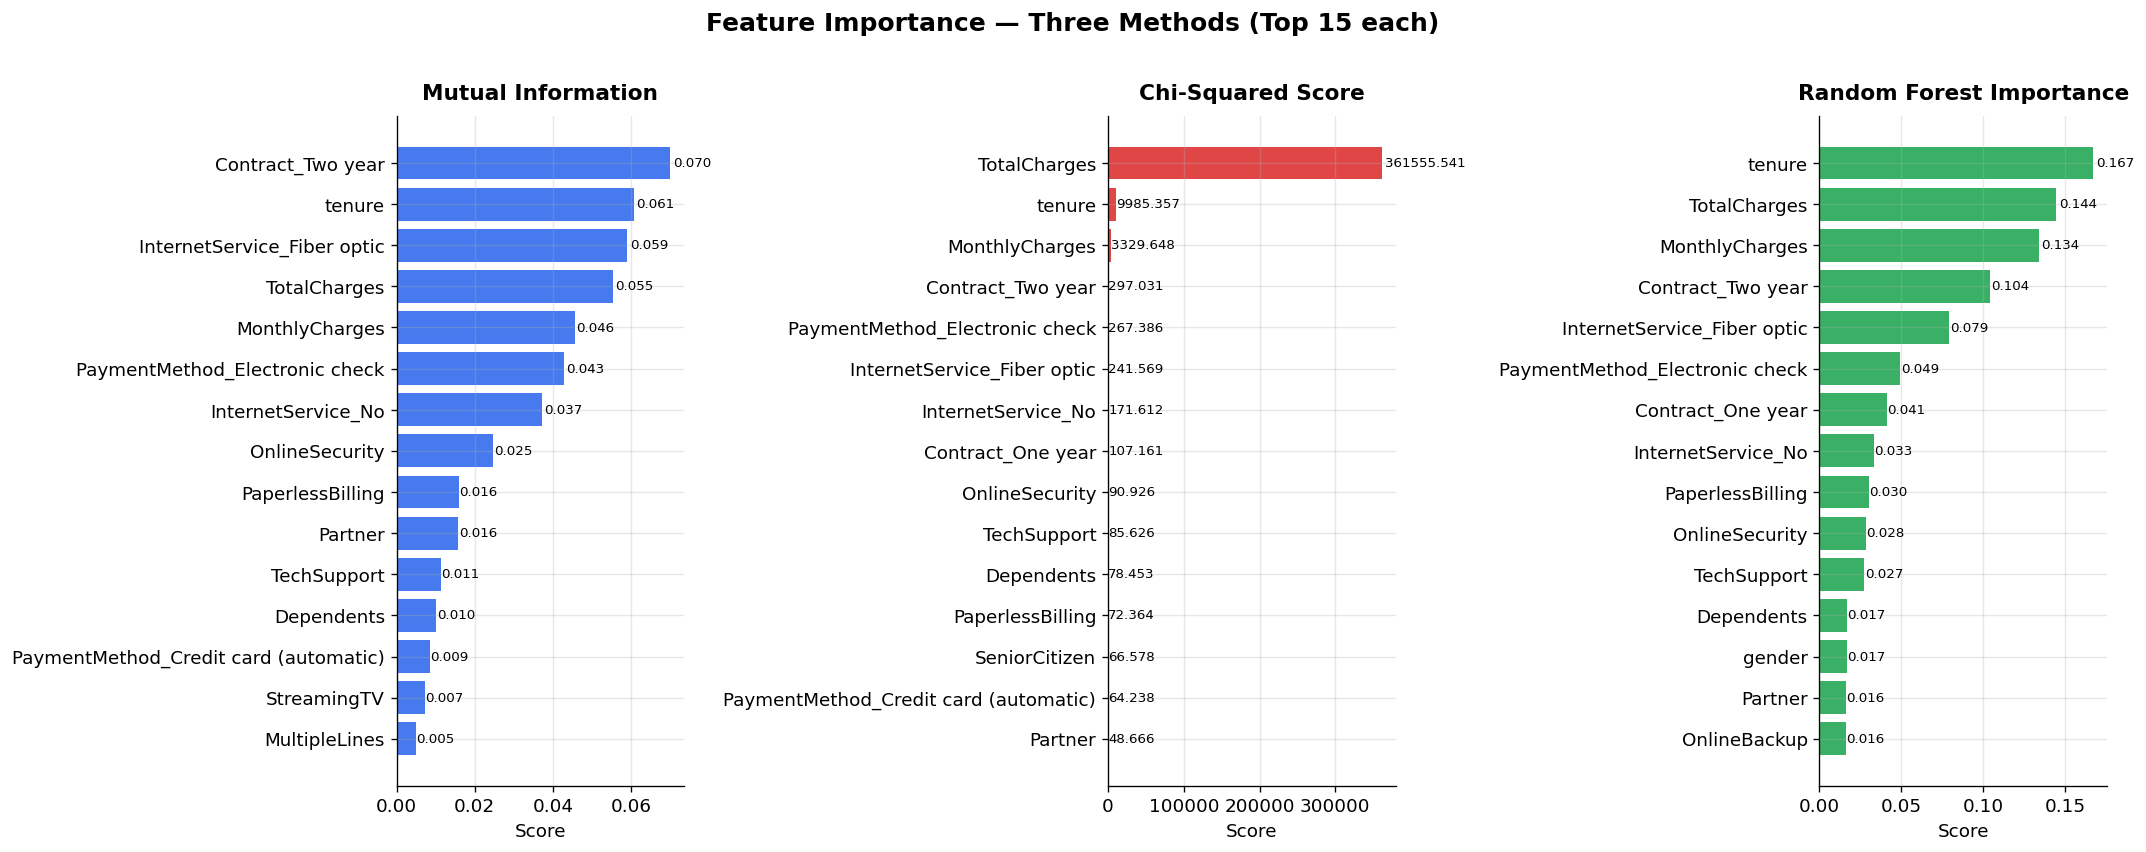

In [61]:
# ─────────────────────────────────────────────────────────────
#  4  Visualise all three methods side-by-side (top 15)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
palette = ['#2563eb', '#dc2626', '#16a34a']

for ax, (title, series, color) in zip(axes, [
    ('Mutual Information',         mi_series,   palette[0]),
    ('Chi-Squared Score',          chi2_series, palette[1]),
    ('Random Forest Importance',   rf_series,   palette[2])
]):
    top = series.head(15).sort_values()
    bars = ax.barh(top.index, top.values, color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Score')
    # Annotate bar values
    for bar, val in zip(bars, top.values):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Three Methods (Top 15 each)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# ─────────────────────────────────────────────────────────────
#  5  Combine scores: normalise each to [0,1] then average
#       This gives a single consensus ranking across all methods
# ─────────────────────────────────────────────────────────────
def normalise(s):
    """Min-max normalise a Series to [0, 1]."""
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-9)

combined = pd.DataFrame({
    'MI'   : normalise(mi_series),
    'Chi2' : normalise(chi2_series),
    'RF'   : normalise(rf_series)
})
combined['avg_score'] = combined.mean(axis=1)
combined = combined.sort_values('avg_score', ascending=False)

print('Combined feature ranking (top 15 — all scores normalised 0-1):')
print(combined.head(15).round(4).to_string())

Combined feature ranking (top 15 — all scores normalised 0-1):
                                        MI  Chi2   RF  avg_score
TotalCharges                          0.79  1.00 0.86       0.88
tenure                                0.87  0.03 1.00       0.63
Contract_Two year                     1.00  0.00 0.60       0.53
MonthlyCharges                        0.65  0.01 0.79       0.48
InternetService_Fiber optic           0.84  0.00 0.45       0.43
PaymentMethod_Electronic check        0.61  0.00 0.26       0.29
InternetService_No                    0.53  0.00 0.16       0.23
OnlineSecurity                        0.35  0.00 0.13       0.16
PaperlessBilling                      0.23  0.00 0.14       0.12
TechSupport                           0.16  0.00 0.12       0.10
Partner                               0.22  0.00 0.05       0.09
Contract_One year                     0.00  0.00 0.21       0.07
Dependents                            0.15  0.00 0.06       0.07
PaymentMethod_Credit card (

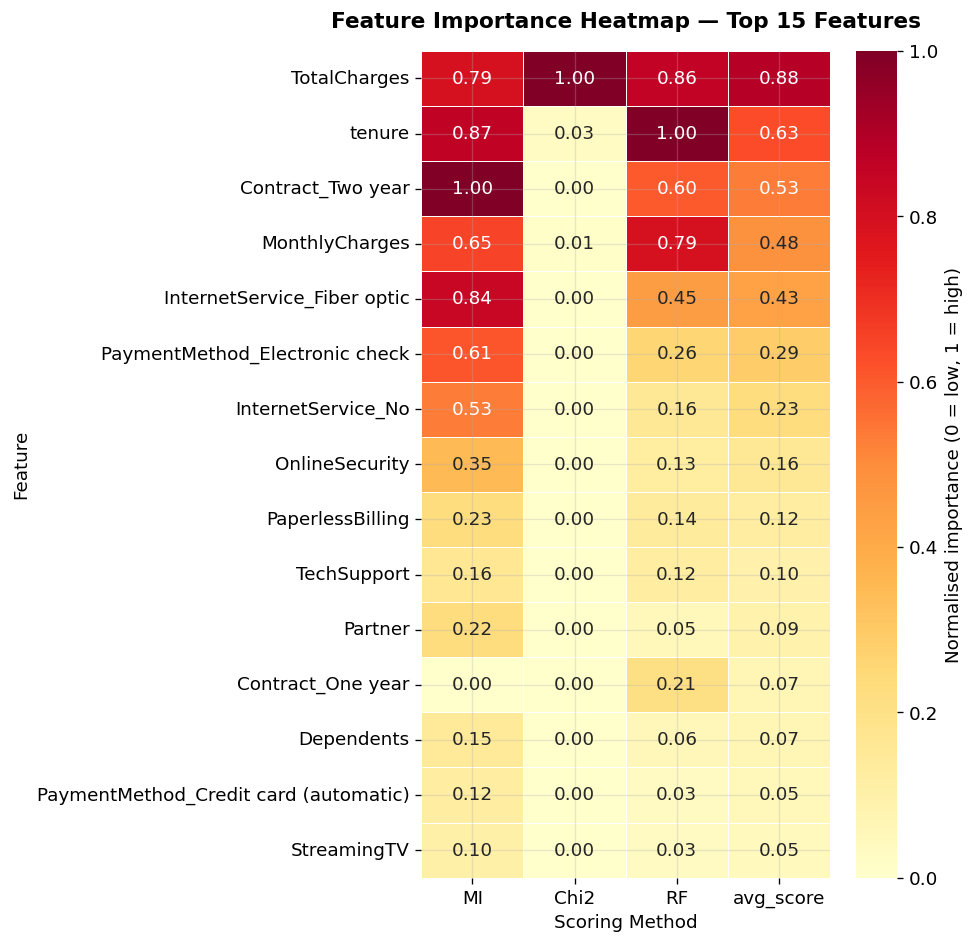

In [63]:
# ─────────────────────────────────────────────────────────────
#  6  Heatmap of combined scores (top 15)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    combined.head(15)[['MI', 'Chi2', 'RF', 'avg_score']],
    annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Normalised importance (0 = low, 1 = high)'}
)
ax.set_title('Feature Importance Heatmap — Top 15 Features',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Scoring Method')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ─────────────────────────────────────────────────────────────
#  6.7  Select features above threshold and subset all splits
#
#  THRESHOLD = 0.10 keeps features with avg normalised score
#  >= 10% of max. Lower this to include more features;
#  raise it to be more aggressive with selection.
# ─────────────────────────────────────────────────────────────
THRESHOLD = 0.10

selected_features = combined[
    combined['avg_score'] >= THRESHOLD
].index.tolist()

print(f'Features selected (avg_score >= {THRESHOLD}): {len(selected_features)}')
for f in selected_features:
    print(f'  · {f:35s}  avg={combined.loc[f, "avg_score"]:.3f}')

# Subset all three splits to selected features only
X_train_sel = X_train_raw[selected_features].copy()
X_val_sel   = X_val[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

print(f'\nReduced shapes:')
print(f'  Train : {X_train_sel.shape}')
print(f'  Val   : {X_val_sel.shape}')
print(f'  Test  : {X_test_sel.shape}')

Features selected (avg_score >= 0.1): 9
  · TotalCharges                         avg=0.883
  · tenure                               avg=0.631
  · Contract_Two year                    avg=0.535
  · MonthlyCharges                       avg=0.483
  · InternetService_Fiber optic          avg=0.430
  · PaymentMethod_Electronic check       avg=0.291
  · InternetService_No                   avg=0.230
  · OnlineSecurity                       avg=0.160
  · PaperlessBilling                     avg=0.122

Reduced shapes:
  Train : (4223, 9)
  Val   : (905, 9)
  Test  : (906, 9)


---
## 15. ⚖️  Scaling <a id='10'></a>

In [65]:
# ─────────────────────────────────────────────────────────────
#  StandardScaler: fit ONLY on training data.
#  Fitting on val/test would leak statistics and inflate scores.
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_sel)   # fit + transform
X_val_sc   = scaler.transform(X_val_sel)          # transform only
X_test_sc  = scaler.transform(X_test_sel)         # transform only

print('✅ Scaling complete (StandardScaler fit on training set only)')
print(f'   Train mean (first 3 features) : {X_train_sc.mean(axis=0)[:3].round(4)}')
print(f'   Train std  (first 3 features) : {X_train_sc.std(axis=0)[:3].round(4)}')
print(f'   Val   mean (first 3 features) : {X_val_sc.mean(axis=0)[:3].round(4)}')

✅ Scaling complete (StandardScaler fit on training set only)
   Train mean (first 3 features) : [ 0. -0. -0.]
   Train std  (first 3 features) : [1. 1. 1.]
   Val   mean (first 3 features) : [ 0.0315 -0.0214 -0.0085]


---
## 16. 🔁 SMOTE (Handle Class Imbalance)<a id='10'></a>

In [66]:
# ─────────────────────────────────────────────────────────────
#  SMOTE generates synthetic minority (churn) samples so models
#  train on a balanced dataset.
#
#  IMPORTANT: SMOTE is applied ONLY to the training set.
#  Val and test remain at real-world distribution (26.5% churn).
# ─────────────────────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_raw)

print('SMOTE oversampling applied to training set only')
print(f'  Before : {len(y_train_raw):,} samples  |  churn rate {y_train_raw.mean()*100:.0f}%')
print(f'  After  : {len(y_train_sm):,} samples  |  churn rate {pd.Series(y_train_sm).mean()*100:.1f}%')
print()
print(f'  Val  unchanged : {len(y_val):,} samples  |  churn rate {y_val.mean()*100:.0f}%')
print(f'  Test unchanged : {len(y_test):,} samples  |  churn rate {y_test.mean()*100:.0f}%')

SMOTE oversampling applied to training set only
  Before : 4,223 samples  |  churn rate 27%
  After  : 6,202 samples  |  churn rate 50.0%

  Val  unchanged : 905 samples  |  churn rate 27%
  Test unchanged : 906 samples  |  churn rate 27%


---
## 17. 🤖 Model Training & Validation<a id='10'></a>

In [67]:
# ─────────────────────────────────────────────────────────────
#  Define all five models with sensible starting hyperparameters.
#  The best model will later be tuned with RandomizedSearchCV.
# ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=0.5,
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Support Vector Machine': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

# ─────────────────────────────────────────────────────────────
#  Train each model and record validation metrics
# ─────────────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f'Training : {name} ...', end=' ')
    model.fit(X_train_sm, y_train_sm)

    y_pred_val  = model.predict(X_val_sc)
    y_proba_val = model.predict_proba(X_val_sc)[:, 1]

    results[name] = {
        'model'        : model,
        'val_accuracy' : accuracy_score(y_val, y_pred_val),
        'val_f1'       : f1_score(y_val, y_pred_val),
        'val_auc'      : roc_auc_score(y_val, y_proba_val),
        'y_pred_val'   : y_pred_val,
        'y_proba_val'  : y_proba_val
    }
    print(f'Acc={results[name]["val_accuracy"]:.3f}  '
          f'F1={results[name]["val_f1"]:.3f}  '
          f'AUC={results[name]["val_auc"]:.3f}')

print('\n✅ All five models trained')

Training : Logistic Regression ... Acc=0.733  F1=0.611  AUC=0.822
Training : Decision Tree ... Acc=0.715  F1=0.581  AUC=0.801
Training : Random Forest ... Acc=0.739  F1=0.600  AUC=0.810
Training : Support Vector Machine ... Acc=0.729  F1=0.608  AUC=0.785
Training : XGBoost ... Acc=0.735  F1=0.588  AUC=0.808

✅ All five models trained


---
## 18. 📋 Classification Reports (Validation Set)<a id='10'></a>

In [68]:
for name, res in results.items():
    print('═' * 64)
    print(f'  {name}')
    print('═' * 64)
    print(classification_report(
        y_val,
        res['y_pred_val'],
        target_names=['No Churn (0)', 'Churn (1)']
    ))
    print()

════════════════════════════════════════════════════════════════
  Logistic Regression
════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

No Churn (0)       0.90      0.71      0.80       664
   Churn (1)       0.50      0.79      0.61       241

    accuracy                           0.73       905
   macro avg       0.70      0.75      0.70       905
weighted avg       0.80      0.73      0.75       905


════════════════════════════════════════════════════════════════
  Decision Tree
════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

No Churn (0)       0.88      0.70      0.78       664
   Churn (1)       0.48      0.74      0.58       241

    accuracy                           0.71       905
   macro avg       0.68      0.72      0.68       905
weighted avg       0.77      0.71      0.73       905


══════════════════════════════════════════════

-----
## 19. 📊  Confusion Matrices (Validation Set) <a id='10'></a>

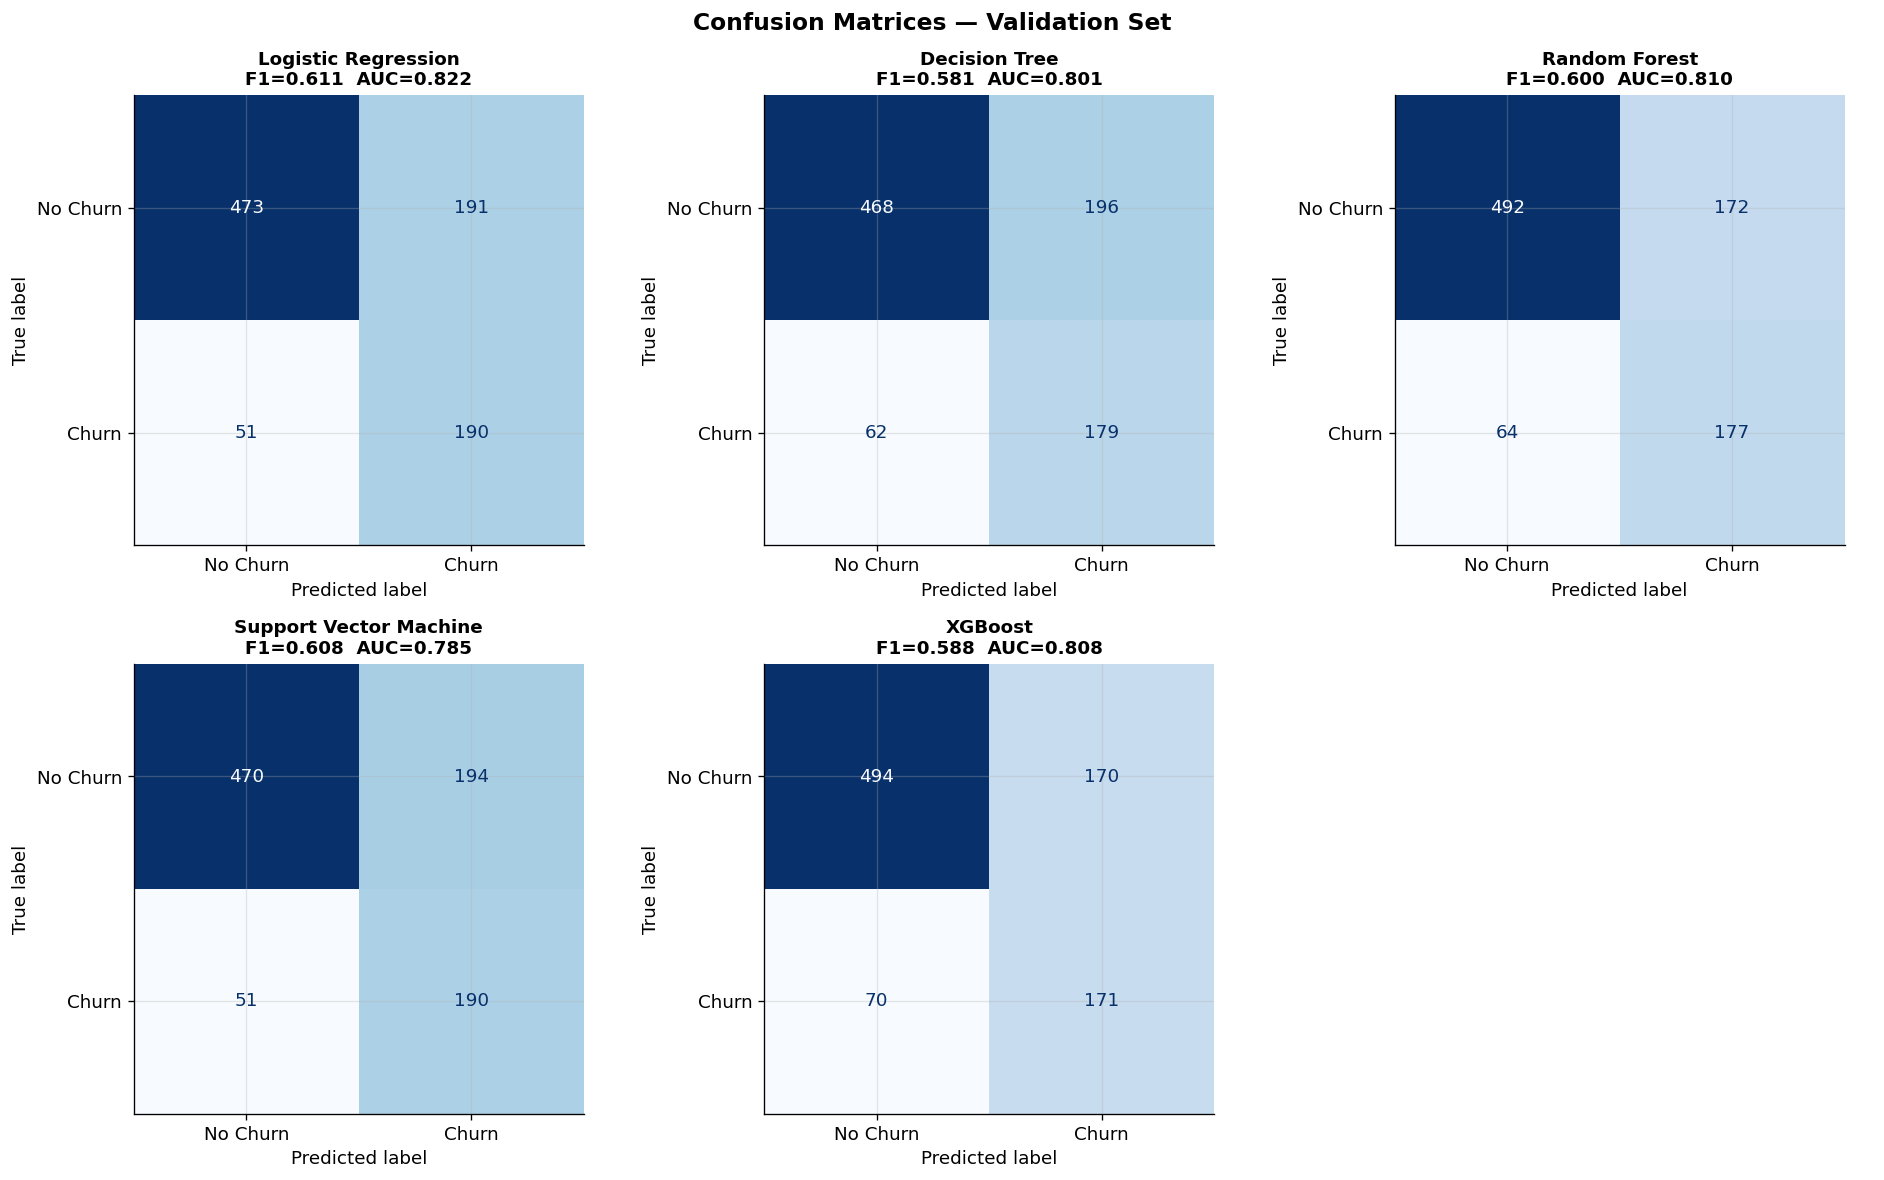

Saved: confusion_matrices.png


In [69]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.ravel()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_val, res['y_pred_val'])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    ).plot(ax=axes_flat[idx], colorbar=False, cmap='Blues')
    axes_flat[idx].set_title(
        f'{name}\nF1={res["val_f1"]:.3f}  AUC={res["val_auc"]:.3f}',
        fontsize=11, fontweight='bold'
    )

axes_flat[-1].axis('off')   # hide unused 6th panel
plt.suptitle('Confusion Matrices — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

----
## 20. 📈 ROC Curves (Validation Set) <a id='10'></a>

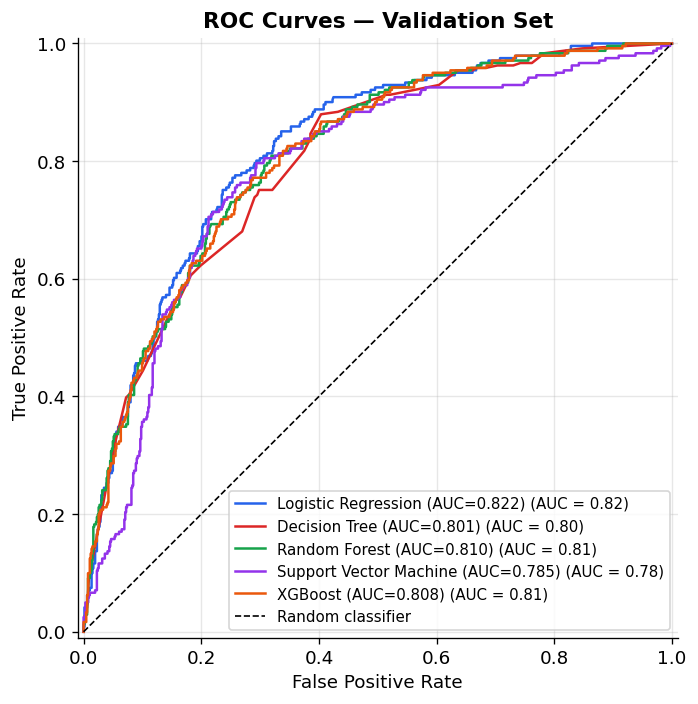

Saved: roc_curves.png


In [70]:
colors = ['#2563eb', '#dc2626', '#16a34a', '#9333ea', '#ea580c']

fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_val,
        res['y_proba_val'],
        name=f"{name} (AUC={res['val_auc']:.3f})",
        ax=ax,
        color=color
    )
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curves — Validation Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## 21.  🏆 Model Comparison Summary <a id='10'></a>

In [71]:
summary_df = pd.DataFrame({
    'Model'          : list(results.keys()),
    'Val Accuracy'   : [r['val_accuracy'] for r in results.values()],
    'Val F1 (Churn)' : [r['val_f1']       for r in results.values()],
    'Val ROC-AUC'    : [r['val_auc']       for r in results.values()]
}).sort_values('Val ROC-AUC', ascending=False).reset_index(drop=True)

print('Model comparison (sorted by ROC-AUC):')
print(summary_df.to_string(index=False))

# Styled display
summary_df.style \
    .format({'Val Accuracy': '{:.4f}', 'Val F1 (Churn)': '{:.4f}', 'Val ROC-AUC': '{:.4f}'}) \
    .highlight_max(subset=['Val Accuracy', 'Val F1 (Churn)', 'Val ROC-AUC'], color='#14532d') \
    .set_caption('Validation Set — Model Comparison (sorted by ROC-AUC)')

Model comparison (sorted by ROC-AUC):
                 Model  Val Accuracy  Val F1 (Churn)  Val ROC-AUC
   Logistic Regression          0.73            0.61         0.82
         Random Forest          0.74            0.60         0.81
               XGBoost          0.73            0.59         0.81
         Decision Tree          0.71            0.58         0.80
Support Vector Machine          0.73            0.61         0.78


,Model,Val Accuracy,Val F1 (Churn),Val ROC-AUC
0,Logistic Regression,0.7326,0.6109,0.8221
1,Random Forest,0.7392,0.6000,0.8100
2,XGBoost,0.7348,0.5876,0.8081
3,Decision Tree,0.7149,0.5812,0.8006
4,Support Vector Machine,0.7293,0.6080,0.7846


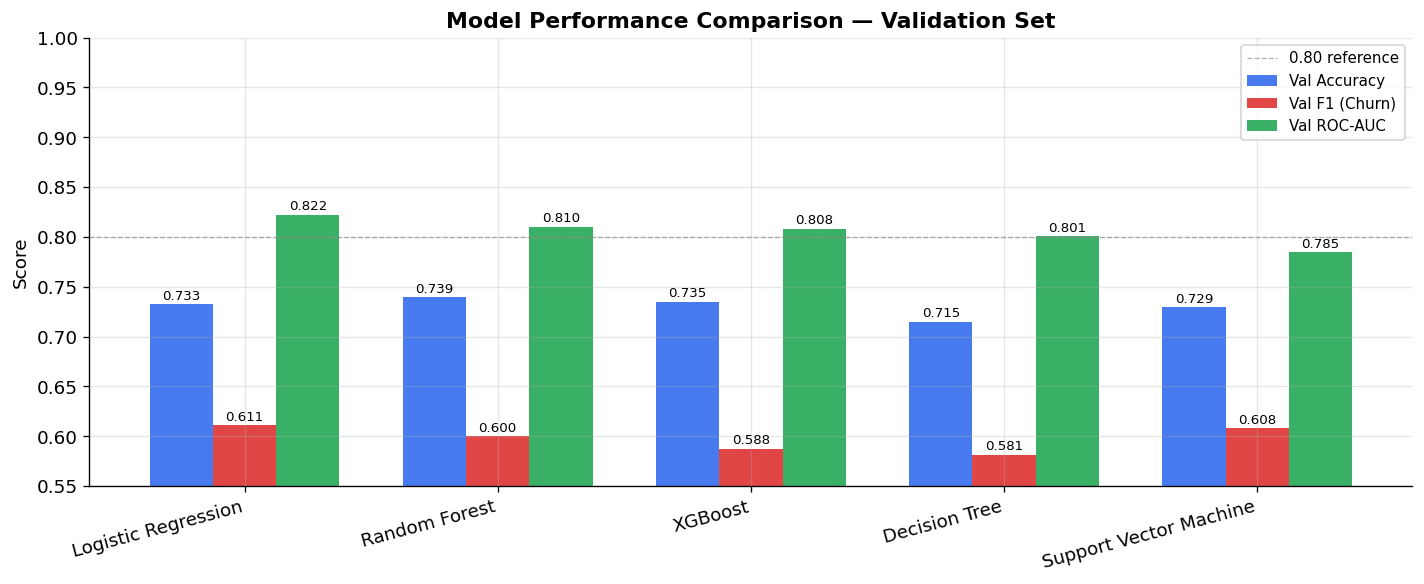

In [72]:
# ── Bar chart comparison ─────────────────────────────────────
metrics = ['Val Accuracy', 'Val F1 (Churn)', 'Val ROC-AUC']
x      = np.arange(len(summary_df))
width  = 0.25
bar_colors = ['#2563eb', '#dc2626', '#16a34a']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i * width, summary_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(summary_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.55, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Validation Set', fontweight='bold')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.80 reference')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. 🔧 Hyperparameter Tuning (Best Model)

In [73]:
# ─────────────────────────────────────────────────────────────
#  Automatically tune whichever model ranked #1 by ROC-AUC.
#  RandomizedSearchCV runs 40 random parameter combinations
#  with 5-fold stratified cross-validation.
# ─────────────────────────────────────────────────────────────
best_model_name = summary_df.iloc[0]['Model']
print(f'Best model on validation set : {best_model_name}')
print(f'Launching RandomizedSearchCV (40 iterations, 5-fold CV)...\n')

# ── Parameter grids per model ────────────────────────────────
param_grids = {
    'XGBoost': {
        'n_estimators'    : [200, 400, 600],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'gamma'           : [0, 0.1, 0.3]
    },
    'Random Forest': {
        'n_estimators'    : [200, 400, 600],
        'max_depth'       : [6, 10, 14, None],
        'min_samples_leaf': [2, 5, 10],
        'max_features'    : ['sqrt', 'log2', 0.5]
    },
    'Logistic Regression': {
        'C'      : [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
        'solver' : ['lbfgs', 'saga'],
        'penalty': ['l2']
    },
    'Support Vector Machine': {
        'C'     : [0.1, 0.5, 1.0, 5.0, 10.0],
        'gamma' : ['scale', 'auto', 0.01, 0.001],
        'kernel': ['rbf', 'poly']
    },
    'Decision Tree': {
        'max_depth'       : [4, 6, 8, 10, None],
        'min_samples_leaf': [5, 10, 20, 50],
        'criterion'       : ['gini', 'entropy']
    }
}

# ── Fresh base estimators (no warm-start bias) ───────────────
base_estimators = {
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    'Support Vector Machine': SVC(
        probability=True, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator   = base_estimators[best_model_name],
    param_distributions = param_grids[best_model_name],
    n_iter      = 40,
    scoring     = 'roc_auc',
    cv          = cv,
    verbose     = 1,
    random_state= RANDOM_STATE,
    n_jobs      = -1
)

search.fit(X_train_sm, y_train_sm)

print(f'\n✅ Search complete')
print(f'   Best CV ROC-AUC : {search.best_score_:.4f}')
print(f'   Best params     : {search.best_params_}')

tuned_model = search.best_estimator_

Best model on validation set : Logistic Regression
Launching RandomizedSearchCV (40 iterations, 5-fold CV)...

Fitting 5 folds for each of 14 candidates, totalling 70 fits

✅ Search complete
   Best CV ROC-AUC : 0.8429
   Best params     : {'solver': 'saga', 'penalty': 'l2', 'C': 5.0}


## 23. 🎯  Decision Threshold Optimisation

Default threshold (0.50) → F1 = 0.6119
Optimal threshold (0.55) → F1 = 0.6227
Improvement : +0.0108


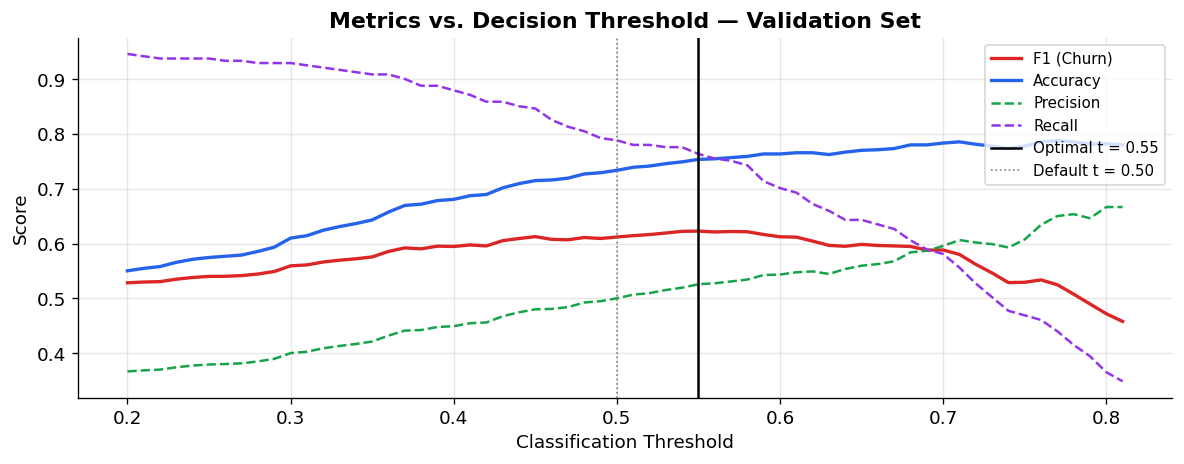

In [74]:
# ─────────────────────────────────────────────────────────────
#  The default threshold of 0.5 is almost always wrong for
#  imbalanced data. We sweep thresholds on the VALIDATION set
#  and pick the one that maximises F1 for the churn class.
# ─────────────────────────────────────────────────────────────
y_proba_val_tuned = tuned_model.predict_proba(X_val_sc)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.01)
f1_scores, acc_scores, precision_scores, recall_scores = [], [], [], []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_t = (y_proba_val_tuned >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    acc_scores.append(accuracy_score(y_val, y_pred_t))
    precision_scores.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_t, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1_thresh = max(f1_scores)
default_f1     = f1_score(y_val, (y_proba_val_tuned >= 0.50).astype(int))

print(f'Default threshold (0.50) → F1 = {default_f1:.4f}')
print(f'Optimal threshold ({best_threshold:.2f}) → F1 = {best_f1_thresh:.4f}')
print(f'Improvement : +{(best_f1_thresh - default_f1):.4f}')

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores,        label='F1 (Churn)',  color='#dc2626', linewidth=2)
ax.plot(thresholds, acc_scores,       label='Accuracy',    color='#2563eb', linewidth=2)
ax.plot(thresholds, precision_scores, label='Precision',   color='#16a34a', linewidth=1.5, linestyle='--')
ax.plot(thresholds, recall_scores,    label='Recall',      color='#9333ea', linewidth=1.5, linestyle='--')
ax.axvline(best_threshold, color='black',  linestyle='-',  linewidth=1.5,
           label=f'Optimal t = {best_threshold:.2f}')
ax.axvline(0.50,            color='gray',  linestyle=':',  linewidth=1.0,
           label='Default t = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs. Decision Threshold — Validation Set', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

## 24. 🧪  Final Evaluation on Held-Out Test Set

In [75]:
# ─────────────────────────────────────────────────────────────
#  The test set is touched ONCE here — never before.
#  We compare default vs optimised threshold side by side.
# ─────────────────────────────────────────────────────────────
y_proba_test = tuned_model.predict_proba(X_test_sc)[:, 1]

for label, thresh in [
    ('Default threshold  (0.50)', 0.50),
    (f'Optimised threshold ({best_threshold:.2f})', best_threshold)
]:
    y_pred = (y_proba_test >= thresh).astype(int)
    print('═' * 64)
    print(f'  {best_model_name} — {label}')
    print('═' * 64)
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  F1 Score : {f1_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_test):.4f}')
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=['No Churn (0)', 'Churn (1)']
    ))
    print()

════════════════════════════════════════════════════════════════
  Logistic Regression — Default threshold  (0.50)
════════════════════════════════════════════════════════════════
  Accuracy : 0.7472
  F1 Score : 0.6164
  ROC-AUC  : 0.8370

              precision    recall  f1-score   support

No Churn (0)       0.90      0.74      0.81       665
   Churn (1)       0.52      0.76      0.62       241

    accuracy                           0.75       906
   macro avg       0.71      0.75      0.71       906
weighted avg       0.80      0.75      0.76       906


════════════════════════════════════════════════════════════════
  Logistic Regression — Optimised threshold (0.55)
════════════════════════════════════════════════════════════════
  Accuracy : 0.7693
  F1 Score : 0.6301
  ROC-AUC  : 0.8370

              precision    recall  f1-score   support

No Churn (0)       0.89      0.78      0.83       665
   Churn (1)       0.55      0.74      0.63       241

    accuracy             

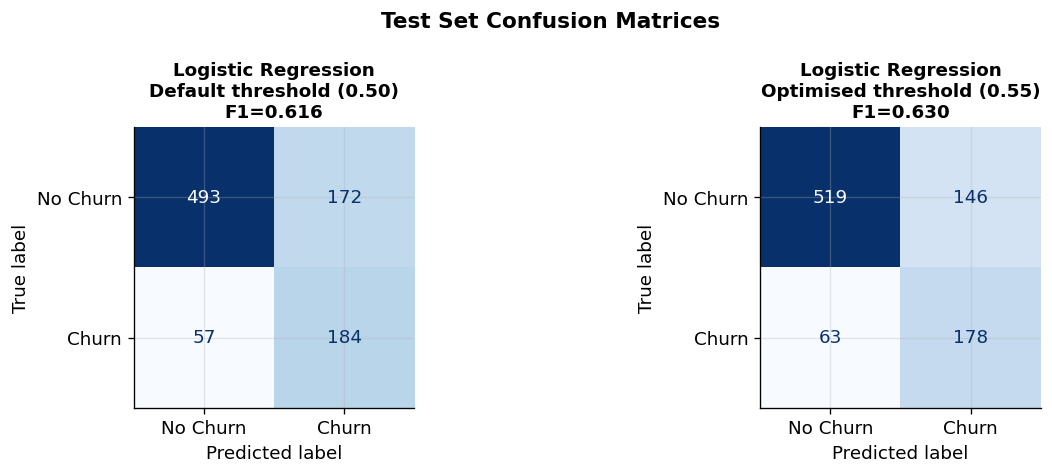

In [76]:
# ── Side-by-side confusion matrices: default vs optimised ────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (label, thresh) in zip(axes, [
    ('Default threshold (0.50)',            0.50),
    (f'Optimised threshold ({best_threshold:.2f})', best_threshold)
]):
    y_pred = (y_proba_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=['No Churn', 'Churn']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f'{best_model_name}\n{label}\nF1={f1_score(y_test,y_pred):.3f}',
        fontweight='bold', fontsize=11
    )

plt.suptitle('Test Set Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 25. 📌 Feature Importance of Final Tuned Model

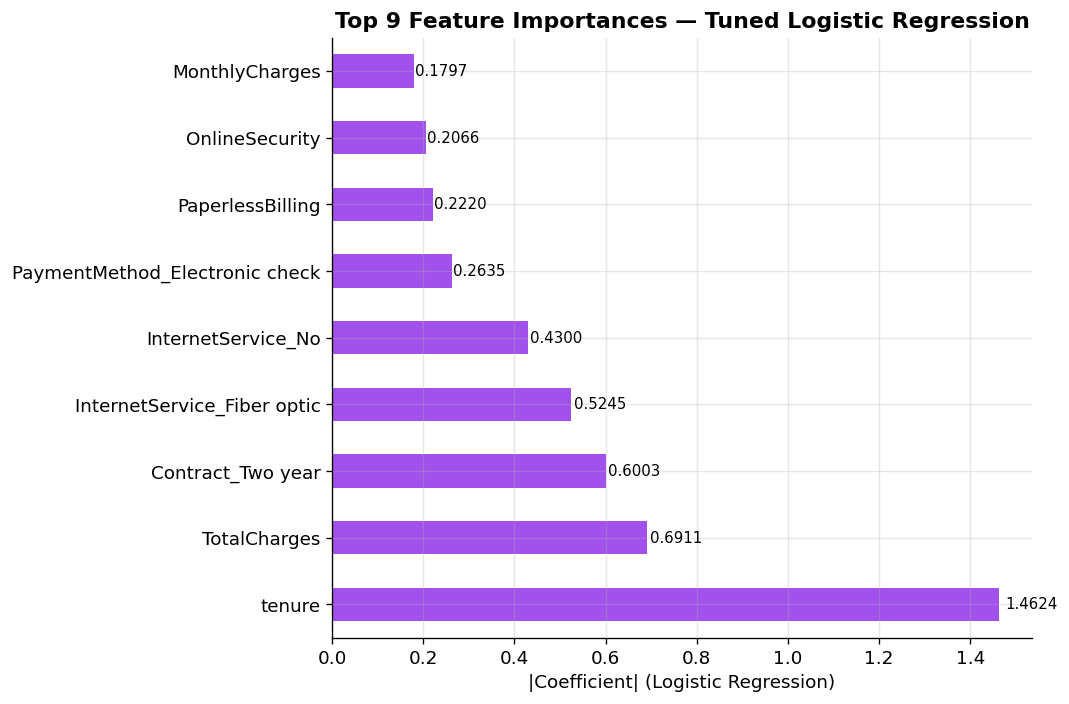

tenure                           1.46
TotalCharges                     0.69
Contract_Two year                0.60
InternetService_Fiber optic      0.52
InternetService_No               0.43
PaymentMethod_Electronic check   0.26
PaperlessBilling                 0.22
OnlineSecurity                   0.21
MonthlyCharges                   0.18


In [77]:
if hasattr(tuned_model, 'feature_importances_'):
    imp = pd.Series(
        tuned_model.feature_importances_, index=selected_features
    ).sort_values(ascending=False)
    imp_label = 'Feature Importance'
    bar_color = '#2563eb'

elif hasattr(tuned_model, 'coef_'):
    imp = pd.Series(
        np.abs(tuned_model.coef_[0]), index=selected_features
    ).sort_values(ascending=False)
    imp_label = '|Coefficient| (Logistic Regression)'
    bar_color = '#9333ea'

else:
    imp = None
    print(f'{best_model_name} does not expose feature importances directly.')

if imp is not None:
    top_n = min(15, len(imp))
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.head(top_n).sort_values().plot(
        kind='barh', ax=ax, color=bar_color, alpha=0.85
    )
    ax.invert_yaxis()
    for bar in ax.patches:
        ax.text(bar.get_width() * 1.01,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=9)
    ax.set_title(f'Top {top_n} Feature Importances — Tuned {best_model_name}',
                 fontweight='bold')
    ax.set_xlabel(imp_label)
    plt.tight_layout()
    plt.savefig('final_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(imp.head(top_n).round(4).to_string())

## 26. 💾 Save All Artefacts

In [78]:
import joblib

joblib.dump(tuned_model,       'tuned_churn_model.pkl')
joblib.dump(scaler,            'churn_scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

# Save threshold too
import json
with open('model_config.json', 'w') as f:
    json.dump({
        'model_name'        : best_model_name,
        'optimal_threshold' : round(float(best_threshold), 2),
        'selected_features' : selected_features,
        'val_auc'           : round(results[best_model_name]['val_auc'], 4)
    }, f, indent=2)

print('✅ Artefacts saved:')
print('   tuned_churn_model.pkl   — trained model')
print('   churn_scaler.pkl        — fitted StandardScaler')
print('   selected_features.pkl   — list of selected feature names')
print('   model_config.json       — threshold + metadata')

print(f"""
── How to predict on new customers ─────────────────────────
import joblib, json, pandas as pd

model    = joblib.load('tuned_churn_model.pkl')
scaler   = joblib.load('churn_scaler.pkl')
features = joblib.load('selected_features.pkl')
config   = json.load(open('model_config.json'))
THRESHOLD = config['optimal_threshold']   # {best_threshold:.2f}

# new_df must have the same columns and pre-processing as training
X_new   = scaler.transform(new_df[features])
proba   = model.predict_proba(X_new)[:, 1]
preds   = (proba >= THRESHOLD).astype(int)   # 1 = will churn
""")

✅ Artefacts saved:
   tuned_churn_model.pkl   — trained model
   churn_scaler.pkl        — fitted StandardScaler
   selected_features.pkl   — list of selected feature names
   model_config.json       — threshold + metadata

── How to predict on new customers ─────────────────────────
import joblib, json, pandas as pd

model    = joblib.load('tuned_churn_model.pkl')
scaler   = joblib.load('churn_scaler.pkl')
features = joblib.load('selected_features.pkl')
config   = json.load(open('model_config.json'))
THRESHOLD = config['optimal_threshold']   # 0.55

# new_df must have the same columns and pre-processing as training
X_new   = scaler.transform(new_df[features])
proba   = model.predict_proba(X_new)[:, 1]
preds   = (proba >= THRESHOLD).astype(int)   # 1 = will churn

